# Inference Speedup Benchmark

> Guide to CUDA GPU inference optimizations, benchmarked on a state-of-the-art PyTorch depth estimation model.

- image: images/2026-03-24-inference_optimizations_benchmark/image.webp
- date:   2026-03-24 15:21:23 -0700
- author: Zeeshan Khan Suri
- toc: true
- badges: true
- comments: true
- categories: [runtime-optimization, gpu, deep-learning]

How fast can we push a single forward pass of a modern depth estimator on a CUDA GPU?
Let's find out with a systematic exploration of every major optimization technique:

| § | Method | Key idea |
|---|--------|----------|
| **§1** | **Baseline (eager)** | all extras disabled; clean reference point |
| **§2** | **Runtime Flags** | |
| 2.1 | `cudnn.benchmark` | auto-tune conv algorithms |
| 2.2 | `channels_last` | NHWC memory layout |
| 2.3 | `inference_mode` | stricter than `no_grad` |
| 2.4 | TF32 matmul | Ampere fast-math for float32 |
| **§3** | **`torch.compile`** | |
| 3.1 | compile (default) | Dynamo + Inductor + Triton |
| 3.2 | compile (reduce-overhead) | + automatic CUDA Graphs |
| 3.3 | compile (max-autotune) | exhaustive kernel search |
| 3.4 | compile fullgraph + freeze | zero graph breaks |
| 3.5 | compile fullgraph + FP16 | the "GPT, Fast" recipe |
| **§4** | **Attention Backends** | |
| 4.1 | SDPA backends | Flash / MemEfficient / Math |
| 4.2 | Triton fused softmax | custom Triton kernel |
| **§5** | **Precision & Quantization** | |
| 5.1 | AMP FP16 | autocast to half precision |
| 5.2 | AMP BF16 | autocast to bfloat16 |
| 5.3 | Static FP16 | `model.half()` permanently |
| 5.4 | torchao int8 weight-only | int8 weights, fp32 activations |
| 5.5 | torchao int8 dynamic | int8 weights + activations |
| 5.6 | torchao int4 weight-only | 4-bit Triton kernels |
| 5.7 | bitsandbytes int8 | LLM.int8() mixed-precision |
| 5.8 | bitsandbytes NF4 | 4-bit NormalFloat |
| **§6** | **ONNX Runtime** | |
| 6.1 | ORT CUDA EP | ORT graph optimizations |
| 6.2 | ORT IO Binding | zero-copy GPU inference |
| 6.3 | ORT optimized + simplified | onnxoptimizer + onnxsim |
| **§7** | **TensorRT** | |
| 7.1 | TRT 8.6 FP16 | native TRT engine with GraphSurgeon |
| 7.2 | TRT 8.6 INT8 | entropy-calibrated quantization |
| 7.3 | ORT TensorRT EP | TRT via ORT |
| 7.4 | Torch-TensorRT | direct TRT from PyTorch |
| **§8** | **Graph Capture & Export** | |
| 8.1 | JIT Trace | TorchScript graph fusion |
| 8.2 | CUDA Graphs | replay captured kernel sequence |
| 8.3 | AOTInductor | ahead-of-time compiled .so |
| 8.4 | Multi-stream pipelining | batch split across streams |
| **§9** | **Sparsity** | |
| 9.1 | Pruning 50% | unstructured L1 magnitude |
| 9.2 | Pruning + compile | sparsity + Inductor |
| **§10** | **Ultimate Combo** | stack everything that helps |

**Methodology:**

- We benchmark a full depth estimator (not just an encoder) so we can verify output correctness.
- **Sanity checks:** Every optimization is validated against the baseline depth map.
  `bench()` computes MSE on a real-image prediction — divergent outputs trigger a
  side-by-side depth visualization.
- Every benchmark cell calls `reset_backends()` first so optimizations never stack accidentally.
- A GPU warmup pass runs before each timed section.
- Each method runs **5 independent rounds** of `blocked_autorange`; we report the **median of medians**.



In [ ]:
# ── Self-contained installs for Colab / Kaggle ─────────────────────────────────
# Tested with PyTorch 2.5 + CUDA 12.1.
# The cu121 wheels are forward-compatible with newer CUDA drivers (12.4, 12.8).

%pip install -q torch==2.5.1+cu121 torchvision==0.20.1+cu121 torchaudio==2.5.1+cu121 \
    --index-url https://download.pytorch.org/whl/cu121
# depth_anything_3: --no-deps avoids pulling a newer PyTorch.
# Warnings about missing optional deps (open3d, xformers …) are harmless.
%pip install -q "depth_anything_3 @ git+https://github.com/ByteDance-Seed/depth-anything-3" --no-deps
%pip install -q "numpy<2" e3nn einops "evo>=0.3" omegaconf safetensors addict \
    pillow opencv-python-headless
%pip install -q torchao bitsandbytes onnxruntime-gpu matplotlib
%pip install -q tensorrt==8.6.1.post1 onnx-graphsurgeon onnxoptimizer onnxsim==0.4.36
%pip install -q pytorch-quantization --no-build-isolation
print("All dependencies installed.")

ERROR: Could not install packages due to an OSError: HTTPSConnectionPool(host='download-r2.pytorch.org', port=443): Max retries exceeded with url: /whl/cu121/torchaudio-2.5.1%2Bcu121-cp311-cp311-linux_x86_64.whl (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1016)')))

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
All dependencies installed.


System info:

In [ ]:
#collapse-hide
from __future__ import annotations

import gc
import os
import warnings

import numpy as np
import torch
import torch.nn as nn
from torch.profiler import ProfilerActivity, profile

warnings.filterwarnings("ignore")

# Suppress noisy C++ warnings from TRT, protobuf, ORT at the process level
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["PYTHONWARNINGS"] = "ignore"

# Suppress torch.compile graph break warnings
import logging
logging.getLogger("torch._dynamo").setLevel(logging.ERROR)
logging.getLogger("torch._inductor").setLevel(logging.ERROR)

# ── Environment setup for TensorRT 8.6 + cuDNN 8 ────────────────────────
import ctypes, pathlib

_site = pathlib.Path(torch.__file__).resolve().parent.parent
_trt_libs = _site / "tensorrt_libs"
_cudnn8_dir = pathlib.Path.cwd() / ".venv" / "lib" / "cudnn8"

# cuDNN 8 (for TRT 8.6) lives in .venv/lib/cudnn8/ alongside cuDNN 9 (for PyTorch)
for _lib_dir in [_cudnn8_dir, _trt_libs]:
    _d = str(_lib_dir)
    if os.path.isdir(_d):
        _ld = os.environ.get("LD_LIBRARY_PATH", "")
        if _d not in _ld:
            os.environ["LD_LIBRARY_PATH"] = f"{_d}:{_ld}"
        # Pre-load shared libs so TRT can find them
        for _so in sorted(pathlib.Path(_d).glob("*.so.*")):
            try:
                ctypes.CDLL(str(_so), mode=ctypes.RTLD_GLOBAL)
            except OSError:
                pass

for _cand in ("/usr/local/cuda", "/usr/local/cuda-12.1", "/usr/local/cuda-12"):
    if os.path.isdir(_cand) and os.path.isfile(os.path.join(_cand, "bin", "nvcc")):
        os.environ.setdefault("CUDA_HOME", _cand)
        break

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    cap = torch.cuda.get_device_capability(0)
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"(SM {cap[0]}.{cap[1]})")
    print(f"VRAM: {mem_gb:.1f} GB")
try:
    import tensorrt as trt
    print(f"TensorRT {trt.__version__}")
except ImportError:
    print("TensorRT: not available")

PyTorch 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
GPU: Tesla V100-DGXS-32GB (SM 7.0)
VRAM: 34.1 GB
TensorRT 8.6.1


## Model: Depth Anything v3 - Metric-Large

ByteDance's monocular metric depth estimator - **334 M params**:
- **Backbone:** DinoV2 ViT-L/14 (304 M) - self-supervised vision transformer
- **Head:** DPT (30 M) - dense prediction transformer for depth regression

Input: a single RGB image `(B, 1, 3, 504, 504)`.
Output: metric depth map `(B, 1, 504, 504)`.

Since the backbone is a **Vision Transformer** the optimization landscape is matmul-heavy:
- **SDPA / FlashAttention** is a primary target
- **FP16 / TF32** have outsized impact
- **`channels_last`** has less impact (mostly linear layers)
- **`torch.compile`** can fuse attention + FFN blocks effectively

Load the model:

In [ ]:
#collapse-hide
from depth_anything_3.api import DepthAnything3
from pathlib import Path

BATCH = 1
IMG_SIZE = 504
MODEL_NAME = "da3-large"
WEIGHTS_PATH = Path("model.safetensors")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class DA3Depth(nn.Module):
    """Benchmark-friendly wrapper: returns just the depth tensor."""

    def __init__(self, da3_api):
        super().__init__()
        self.net = da3_api.model  # DepthAnything3Net

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.net(x, export_feat_layers=[])
        return out["depth"]


# ── Build model & load weights ───────────────────────────────────────────
_api = DepthAnything3(model_name=MODEL_NAME)
_weights_loaded = False

# Try from_pretrained (needs HuggingFace Hub connectivity)
if not _weights_loaded:
    try:
        _api_pre = DepthAnything3.from_pretrained(f"depth-anything/{MODEL_NAME}")
        _api = _api_pre
        _weights_loaded = True
        print("Weights: loaded via from_pretrained (HuggingFace Hub)")
    except Exception as _e:
        print(f"from_pretrained unavailable: {type(_e).__name__}")

# If not, load from local safetensors file
if not _weights_loaded and WEIGHTS_PATH.exists():
    from safetensors.torch import load_file as _load_safetensors

    _sd = _load_safetensors(str(WEIGHTS_PATH))
    _sd = {k.replace("model.", "", 1): v for k, v in _sd.items()}
    _result = _api.model.load_state_dict(_sd, strict=False)
    _weights_loaded = True
    print(
        f"Weights: loaded from {WEIGHTS_PATH}  "
        f"(matched {len(_sd) - len(_result.unexpected_keys)}/{len(_sd)} keys, "
        f"{len(_result.missing_keys)} missing)"
    )

if not _weights_loaded:
    print("Weights: random init (benchmark timings are still valid)")

model = DA3Depth(_api).to(device).eval()

dummy_input = torch.randn(BATCH, 1, 3, IMG_SIZE, IMG_SIZE, device=device)
with torch.no_grad():
    baseline_output = model(dummy_input)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model  : Depth Anything v3 ({MODEL_NAME})")
print(f"Params : {n_params:.1f} M")
print(f"Input  : {tuple(dummy_input.shape)} - (B, N_views, C, H, W)")
print(f"Output : {tuple(baseline_output.shape)} - metric depth map")

[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70
[INFO ] using MLP layer as FFN
[INFO ] using MLP layer as FFN


model.safetensors:   0%|          | 0.00/1.64G [00:00<?, ?B/s]

from_pretrained unavailable: RuntimeError
Weights: loaded from model.safetensors  (matched 637/637 keys, 6 missing)
Model  : Depth Anything v3 (da3-large)
Params : 410.9 M
Input  : (1, 1, 3, 504, 504) - (B, N_views, C, H, W)
Output : (1, 1, 504, 504) - metric depth map


Load the test image and test the model:

Downloaded test image: (1546, 1213)
Depth range: [0.8860, 2.6241]


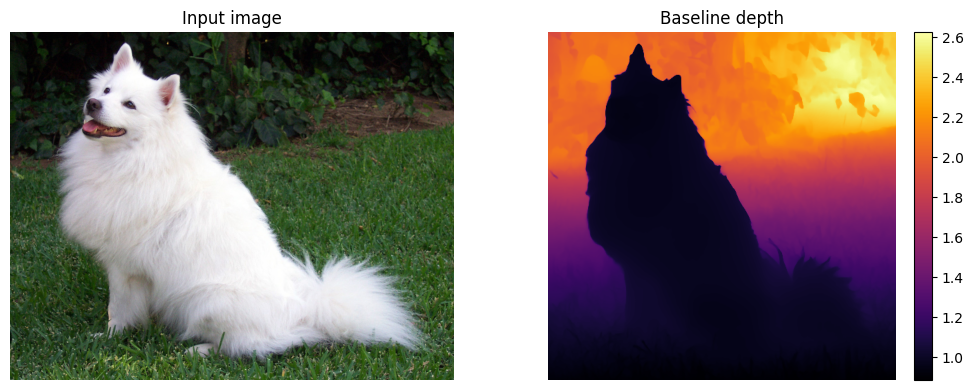

In [ ]:
#collapse-hide
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image as _PILImage
from torchvision import transforms as T
from urllib.request import urlopen
import io as _io

# Download a real test image (GitHub-hosted)
_IMG_URL = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
try:
    _resp = urlopen(_IMG_URL, timeout=15)
    SANITY_IMG = _PILImage.open(_io.BytesIO(_resp.read())).convert("RGB")
    print(f"Downloaded test image: {SANITY_IMG.size}")
except Exception:
    print("Image download failed - using synthetic test image")
    SANITY_IMG = _PILImage.fromarray(
        np.random.default_rng(42).integers(0, 255, (256, 256, 3), dtype=np.uint8)
    )

# Prepare real image as model input
_sanity_transform = T.Compose(
    [
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)
SANITY_INPUT = _sanity_transform(SANITY_IMG).unsqueeze(0).unsqueeze(0).to(device)
# shape: (1, 1, 3, 504, 504)

with torch.no_grad():
    SANITY_DEPTH_REF = model(SANITY_INPUT)

# ── Show the input image and baseline depth ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(SANITY_IMG)
axes[0].set_title("Input image")
axes[0].axis("off")

depth_np = SANITY_DEPTH_REF[0, 0].cpu().numpy()
print(f"Depth range: [{depth_np.min():.4f}, {depth_np.max():.4f}]")
im = axes[1].imshow(depth_np, cmap="inferno")
axes[1].set_title("Baseline depth")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
plt.close(fig)

## Benchmarking utilities

Every method gets timed the same way: `torch.utils.benchmark.Timer` with
`blocked_autorange`, repeated for `N_ROUNDS` independent rounds. We report
the **median of medians**.

Key helpers:
- **`bench()`** - timing with GPU clock warmup + 5 rounds of `blocked_autorange`
- **`sanity_check()`** - compare depth map vs baseline; show side-by-side on failure
- **`fresh_model()`** - clean model copy so no optimization leaks between cells
- **`reset_backends()`** - disable all global toggles (TF32, cudnn.benchmark, etc.)

In [ ]:
#collapse-hide
import time
from contextlib import contextmanager
from statistics import median
import torch.utils.benchmark as _bench_mod

# ── Shared state ─────────────────────────────────────────────────────────
GPU_RESULTS: dict[str, float] = {}
GPU_MEMORY: dict[str, float] = {}  # peak GPU memory in MB per method
SETUP_TIMES: dict[str, float] = {}
MIN_RUN_TIME: float = 3.0
N_ROUNDS: int = 5

# Cache base model weights for fresh_model()
_BASE_STATE_DICT = {k: v.cpu().clone() for k, v in model.state_dict().items()}


def reset_backends() -> None:
    torch.backends.cudnn.benchmark = False
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


_TORCH_COMPILE_OK: bool | None = None


def _check_compile_support() -> bool:
    global _TORCH_COMPILE_OK
    if _TORCH_COMPILE_OK is not None:
        return _TORCH_COMPILE_OK
    try:
        _m = torch.compile(torch.nn.Linear(1, 1).to(device), mode="default")
        with torch.no_grad():
            _m(torch.randn(1, 1, device=device))
        _TORCH_COMPILE_OK = True
    except Exception:
        _TORCH_COMPILE_OK = False
    return _TORCH_COMPILE_OK


def check_output(name, output, reference, atol=0.05):
    if isinstance(output, np.ndarray):
        diff = float(np.max(np.abs(output - reference.cpu().numpy())))
    else:
        diff = (output.float().cpu() - reference.cpu()).abs().max().item()
    status = "OK" if diff < atol else "WARN"
    print(f"  [{status}] {name}: max diff = {diff:.6f} (atol={atol})")


def _gpu_warmup(stmt, globals_dict, n=10):
    t = _bench_mod.Timer(stmt=stmt, globals=globals_dict)
    t.timeit(n)


def bench(
    label,
    stmt,
    globals_dict,
    results=None,
    min_run_time=MIN_RUN_TIME,
    n_rounds=N_ROUNDS,
    sanity=True,
    per_sample=1,
):
    if results is None:
        results = GPU_RESULTS

    _gpu_warmup(stmt, globals_dict)

    # ── Memory measurement (single run) ──
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    _bench_mod.Timer(stmt=stmt, globals=globals_dict).timeit(1)
    torch.cuda.synchronize()
    _peak_mb = torch.cuda.max_memory_allocated() / 1e6
    GPU_MEMORY[label] = _peak_mb

    t = _bench_mod.Timer(stmt=stmt, globals=globals_dict, label=label)
    round_medians = []
    for _ in range(n_rounds):
        m = t.blocked_autorange(min_run_time=min_run_time)
        round_medians.append(m.median * 1e3 / per_sample)
    ms = median(round_medians)
    results[label] = ms
    spread = max(round_medians) - min(round_medians)
    _ps = f"  (per-sample, batch={per_sample})" if per_sample > 1 else ""
    print(
        f"  {label}: {ms:.3f} ms{_ps}  "
        f"(spread: {spread:.3f} ms  "
        f"rounds: {', '.join(f'{r:.2f}' for r in round_medians)})  "
        f"peak VRAM: {_peak_mb:.0f} MB"
    )

    if sanity and SANITY_INPUT is not None:
        _mdl = globals_dict.get("model")
        if _mdl is not None and isinstance(_mdl, nn.Module):
            try:
                _dtype = None
                _ac = None
                try:
                    _fp = next(_mdl.parameters())
                    if _fp.dtype == torch.float16:
                        _dtype = torch.float16
                except StopIteration:
                    pass
                if "autocast" in stmt and "float16" in stmt:
                    _ac = torch.float16
                    _dtype = None
                elif "autocast" in stmt and "bfloat16" in stmt:
                    _ac = torch.bfloat16
                    _dtype = None
                sanity_check(label, _mdl, input_dtype=_dtype, autocast_dtype=_ac)
            except Exception as e:
                print(f"  ⚠ Sanity skip: {type(e).__name__}: {e}")


@contextmanager
def timed(label):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    yield
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    SETUP_TIMES[label] = elapsed
    print(f"  [{label}] setup: {elapsed:.2f} s")


def fresh_model(
    patch_head_fp16: bool = False, patch_rope: bool = False, fullgraph: bool = False
) -> nn.Module:
    """Return a fresh DA3 depth model with cached weights."""
    _api = DepthAnything3(model_name=MODEL_NAME)
    m = DA3Depth(_api)
    m.load_state_dict(_BASE_STATE_DICT, strict=True)
    if patch_head_fp16:
        _patch_da3_head_fp16(m.net)
    m = m.to(device).eval()
    if patch_rope:
        _patch_rope_for_compile(m, dummy_input)
    if fullgraph:
        _patch_fullgraph_forward(m)
    return m


# ── DA3 head FP16 patch ──────────────────────────────────────────────────
from depth_anything_3.model.da3 import DepthAnything3Net as _DA3Net

_da3_orig_forward = _DA3Net.forward
_dpt_orig_activation = None


def _safe_activation(self, x, activation="linear"):
    act = activation.lower() if isinstance(activation, str) else activation
    if act in ("exp", "expp1", "expm1", "softplus"):
        x32 = x.float()
        if act == "exp":
            out = torch.exp(x32)
        elif act == "expp1":
            out = torch.exp(x32) + 1
        elif act == "expm1":
            out = torch.expm1(x32)
        else:
            out = torch.nn.functional.softplus(x32)
        return out.to(x.dtype)
    return _dpt_orig_activation(self, x, activation)


def _da3_forward_fp16(self, x, **kw):
    extrinsics = kw.get("extrinsics")
    intrinsics = kw.get("intrinsics")
    export_feat_layers = kw.get("export_feat_layers", [])
    ref_view_strategy = kw.get("ref_view_strategy", "saddle_balanced")
    use_ray_pose = kw.get("use_ray_pose", False)
    infer_gs = kw.get("infer_gs", False)

    if extrinsics is not None:
        with torch.autocast(device_type=x.device.type, enabled=False):
            cam_token = self.cam_enc(extrinsics, intrinsics, x.shape[-2:])
    else:
        cam_token = None

    feats, aux_feats = self.backbone(
        x,
        cam_token=cam_token,
        export_feat_layers=export_feat_layers,
        ref_view_strategy=ref_view_strategy,
    )
    H, W = x.shape[-2], x.shape[-1]

    output = self._process_depth_head(feats, H, W)
    if use_ray_pose:
        output = self._process_ray_pose_estimation(output, H, W)
    else:
        output = self._process_camera_estimation(feats, H, W, output)
    if infer_gs:
        output = self._process_gs_head(
            feats, H, W, output, x, kw.get("extrinsics"), kw.get("intrinsics")
        )
    output = self._process_mono_sky_estimation(output)
    output.aux = self._extract_auxiliary_features(aux_feats, export_feat_layers, H, W)
    return output


def _patch_da3_head_fp16(net):
    global _dpt_orig_activation
    import types
    from depth_anything_3.model.dpt import DPT as _DPTClass

    if _dpt_orig_activation is None:
        _dpt_orig_activation = _DPTClass._apply_activation_single
    net.forward = types.MethodType(_da3_forward_fp16, net)
    net.head._apply_activation_single = types.MethodType(_safe_activation, net.head)


# ── RoPE compile patch ───────────────────────────────────────────────────
def _patch_rope_for_compile(m, x):
    """Pre-compute RoPE caches and eliminate graph breaks for torch.compile."""
    import types
    from depth_anything_3.model.dinov2.layers.rope import (
        PositionGetter,
        RotaryPositionEmbedding2D,
    )

    net = m.net if hasattr(m, "net") else m

    # Pre-warm all caches
    with torch.no_grad():
        _ = m(x)
    with torch.no_grad():
        with torch.amp.autocast("cuda", dtype=torch.float16):
            _ = m(x)

    # 1. Freeze PositionGetter
    for mod in net.modules():
        if isinstance(mod, PositionGetter):
            (h, w), pos = next(iter(mod.position_cache.items()))
            _frozen_pos = pos.clone()
            _fh, _fw = h, w

            def _frozen_pg(
                self, batch_size, height, width, device, _p=_frozen_pos, _h=_fh, _w=_fw
            ):
                return (
                    _p.to(device).view(1, _h * _w, 2).expand(batch_size, -1, -1).clone()
                )

            mod.__call__ = types.MethodType(_frozen_pg, mod)

    # 2. Freeze RoPE freq cache
    for mod in net.modules():
        if isinstance(mod, RotaryPositionEmbedding2D):
            _fc = {}
            for cache_key, (cos_c, sin_c) in mod.frequency_cache.items():
                dim, seq, dev, dt = cache_key
                norm_dev = torch.device(
                    dev.type, dev.index if dev.index is not None else 0
                )
                _fc[(dim, seq, norm_dev, dt)] = (cos_c.clone(), sin_c.clone())
            _max_seq = max(k[1] for k in _fc)
            # Pre-compute float16 versions (autocast keeps RoPE in FP32)
            for (dim, seq, dev, dt), (cos_c, sin_c) in list(_fc.items()):
                fp16_key = (dim, seq, dev, torch.float16)
                if fp16_key not in _fc:
                    _fc[fp16_key] = (cos_c.to(torch.float16), sin_c.to(torch.float16))

            def _frozen_rope_fwd(self, tokens, positions, _cache=_fc, _seq=_max_seq):
                feature_dim = tokens.size(-1) // 2
                dev = tokens.device
                norm_dev = torch.device(
                    dev.type, dev.index if dev.index is not None else 0
                )
                ck = (feature_dim, _seq, norm_dev, tokens.dtype)
                cos_comp, sin_comp = _cache[ck]
                v, h = tokens.chunk(2, dim=-1)
                v = self._apply_1d_rope(v, positions[..., 0], cos_comp, sin_comp)
                h = self._apply_1d_rope(h, positions[..., 1], cos_comp, sin_comp)
                return torch.cat((v, h), dim=-1)

            mod.forward = types.MethodType(_frozen_rope_fwd, mod)

    # 3. Freeze _prepare_rope - avoid CPU tensor creation during CUDA graph capture
    vit = net.backbone.pretrained
    if vit.rope is not None:
        B, S, _, H, W = x.shape
        _fpos, _fpos_nd = vit._prepare_rope(B, S, H, W, x.device)
        # Positions are int64 indices (for F.embedding) - keep them as-is
        _fpos_frozen = _fpos.clone()
        _fpos_nd_frozen = _fpos_nd.clone()

        def _frozen_prepare_rope(
            self, B, S, H, W, device, _p=_fpos_frozen, _pnd=_fpos_nd_frozen
        ):
            return _p.to(device).clone(), _pnd.to(device).clone()

        vit._prepare_rope = types.MethodType(_frozen_prepare_rope, vit)

    print("  RoPE patched: caches frozen, graph breaks eliminated")


# ── Fullgraph forward patch ──────────────────────────────────────────────
def _patch_fullgraph_forward(m):
    """Replace DA3Depth.forward to avoid addict.Dict for fullgraph compile."""
    import types
    from depth_anything_3.model.utils.head_utils import (
        create_uv_grid,
        position_grid_to_embed,
    )

    def _add_pos_embed_safe(self, x, W, H, ratio=0.1):
        pw, ph = x.shape[-1], x.shape[-2]
        pe = create_uv_grid(pw, ph, aspect_ratio=W / H, dtype=x.dtype, device=x.device)
        pe = position_grid_to_embed(pe, x.shape[1]) * ratio
        pe = pe.to(x.dtype)
        pe = pe.permute(2, 0, 1)[None].expand(x.shape[0], -1, -1, -1)
        return x + pe

    m.net.head._add_pos_embed = types.MethodType(_add_pos_embed_safe, m.net.head)

    def _fullgraph_fwd(self, x):
        net = self.net
        feats, _ = net.backbone(
            x,
            cam_token=None,
            export_feat_layers=[],
            ref_view_strategy="saddle_balanced",
        )
        H, W = x.shape[-2], x.shape[-1]
        B, S, N, C = feats[0][0].shape
        flat_feats = [feat[0].reshape(B * S, N, C) for feat in feats]
        out_dict = net.head._forward_impl(flat_feats, H, W, patch_start_idx=0)
        depth = out_dict["depth"].reshape(B, S, *out_dict["depth"].shape[1:])
        if net.cam_dec is not None:
            cam_feat = feats[-1][1]
            _pose = net.cam_dec.backbone(cam_feat)
        return depth

    m.forward = types.MethodType(_fullgraph_fwd, m)
    print("  Fullgraph forward patched: addict.Dict bypassed")


def cleanup():
    torch._dynamo.reset()
    gc.collect()
    try:
        torch.cuda.empty_cache()
    except RuntimeError:
        pass


def sanity_check(
    name, model_or_out, *, input_dtype=None, autocast_dtype=None, atol_mse=0.5
):
    if isinstance(model_or_out, (torch.Tensor, np.ndarray)):
        out = torch.as_tensor(model_or_out).float()
    else:
        inp = SANITY_INPUT
        if input_dtype is not None:
            inp = inp.to(dtype=input_dtype)
        with torch.no_grad():
            if autocast_dtype is not None:
                with torch.amp.autocast("cuda", dtype=autocast_dtype):
                    out = model_or_out(inp)
            else:
                out = model_or_out(inp)
        out = out.float()

    ref = SANITY_DEPTH_REF.float()
    mse = ((out.cpu() - ref.cpu()) ** 2).mean().item()

    if mse < atol_mse:
        print(f"  ✓ Sanity ({name}): depth MSE = {mse:.6f}")
    else:
        # ── Threshold exceeded — show side-by-side depth maps ────────────
        severity = "⚠" if mse < 5.0 else "✗"
        print(f"  {severity} Sanity ({name}): depth MSE = {mse:.6f}  (threshold {atol_mse})")
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        axes[0].imshow(SANITY_IMG)
        axes[0].set_title("Input image")
        axes[0].axis("off")
        axes[1].imshow(ref[0, 0].cpu().numpy(), cmap="inferno")
        axes[1].set_title("Baseline depth")
        axes[1].axis("off")
        axes[2].imshow(out[0, 0].cpu().numpy(), cmap="inferno")
        axes[2].set_title(f"{name} depth  (MSE={mse:.4f})")
        axes[2].axis("off")
        plt.tight_layout()
        plt.show()
        plt.close(fig)


print("Ready.")

Ready.


### GPU warmup

GPUs start in a low-power state with throttled clocks. We run 50 forward passes
to force clocks up and stabilize cuDNN plan caches before any timing begins.
`bench()` also runs 10 untimed iterations before each timed section.

In [ ]:
print("Warming up GPU...")
with torch.no_grad():
    for _ in range(50):
        _ = model(dummy_input)
torch.cuda.synchronize()
print("GPU warm - clocks boosted and stable.")

Warming up GPU...
GPU warm - clocks boosted and stable.


---
## §1 – Baseline (eager)

All optimization flags disabled. This is our clean reference point — every other
method is measured against this.


In [ ]:
reset_backends()

with torch.no_grad():
    _out = model(dummy_input)
print(f"Baseline output shape: {_out.shape}")

bench(
    "1 - Baseline (eager)",
    "with torch.no_grad(): model(x)",
    {"model": model, "x": dummy_input},
)

Baseline output shape: torch.Size([1, 1, 504, 504])
  1 - Baseline (eager): 174.423 ms  (spread: 0.493 ms  rounds: 173.93, 174.15, 174.43, 174.42, 174.43)  peak VRAM: 2244 MB
  ✓ Sanity (1 - Baseline (eager)): depth MSE = 0.000000


---
# §2 – Runtime Flags

These are single-line toggles that don't change the model itself.

## 2.1 – `cudnn.benchmark`

Let cuDNN auto-tune convolution algorithms for the given input size.
Useful when input dimensions are fixed (which they are for us).


In [ ]:
reset_backends()
torch.backends.cudnn.benchmark = True

bench(
    "2.1 - cudnn.benchmark",
    "with torch.no_grad(): model(x)",
    {"model": model, "x": dummy_input},
)
reset_backends()

  2.1 - cudnn.benchmark: 174.131 ms  (spread: 1.088 ms  rounds: 174.13, 174.38, 174.42, 173.33, 173.38)  peak VRAM: 2244 MB
  ✓ Sanity (2.1 - cudnn.benchmark): depth MSE = 0.000000


---
## 2.2 – `channels_last`

NHWC memory layout. Can speed up convolutions on modern GPUs by matching
hardware-preferred memory access patterns.


In [ ]:
reset_backends()

_m = fresh_model()
# channels_last only applies to 4D tensors; DA3 input is 5D.
_m = _m.to(memory_format=torch.channels_last)


bench(
    "2.2 - channels_last",
    "with torch.no_grad(): model(x)",
    {"model": _m, "x": dummy_input},
)
cleanup()

[INFO ] using MLP layer as FFN
  2.2 - channels_last: 175.338 ms  (spread: 0.600 ms  rounds: 175.60, 175.00, 175.42, 175.29, 175.34)  peak VRAM: 3917 MB
  ✓ Sanity (2.2 - channels_last): depth MSE = 0.000000


---
## 2.3 – `inference_mode`

Stricter than `no_grad` – also disables autograd tracking and version counting,
reducing dispatch overhead.


In [ ]:
reset_backends()

bench(
    "2.3 - inference_mode",
    "with torch.inference_mode(): model(x)",
    {"model": model, "x": dummy_input},
)

  2.3 - inference_mode: 171.411 ms  (spread: 0.329 ms  rounds: 171.39, 171.41, 171.57, 171.41, 171.72)  peak VRAM: 3906 MB
  ✓ Sanity (2.3 - inference_mode): depth MSE = 0.000000


---
## 2.4 – TF32 matmul

Allow TensorFloat-32 for float32 matmuls. This uses Tensor Cores on Ampere+
GPUs for ~3× throughput at slightly reduced mantissa precision. No effect on
pre-Ampere architectures.


In [ ]:
reset_backends()
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

bench(
    "2.4 - TF32 matmul",
    "with torch.no_grad(): model(x)",
    {"model": model, "x": dummy_input},
)
reset_backends()

  2.4 - TF32 matmul: 174.652 ms  (spread: 0.460 ms  rounds: 174.52, 174.65, 174.69, 174.89, 174.43)  peak VRAM: 3906 MB
  ✓ Sanity (2.4 - TF32 matmul): depth MSE = 0.000000


---
# §3 – `torch.compile`

PyTorch 2.x's graph compiler. Dynamo captures the Python code as an FX graph,
then Inductor lowers it to Triton/CUDA kernels with operator fusion.

## 3.1 – compile (default)

Baseline compilation with default settings. Has graph breaks from
`Tensor.item()` calls in the RoPE position encoding.


In [ ]:
reset_backends()

if not _check_compile_support():
    print("torch.compile not supported - skipping")
    GPU_RESULTS["3.1 - compile (default)"] = float("nan")
else:
    _m = fresh_model()
    with timed("compile default"):
        _m = torch.compile(_m, mode="default")
        with torch.no_grad():
            _ = _m(dummy_input)  # trigger compilation

    bench(
        "3.1 - compile (default)",
        "with torch.no_grad(): model(x)",
        {"model": _m, "x": dummy_input},
    )
    cleanup()

[INFO ] using MLP layer as FFN
  [compile default] setup: 21.32 s
  3.1 - compile (default): 144.542 ms  (spread: 0.204 ms  rounds: 144.48, 144.48, 144.59, 144.54, 144.68)  peak VRAM: 3819 MB
  ✓ Sanity (3.1 - compile (default)): depth MSE = 0.000000


---
## 3.2 – compile (reduce-overhead)

Automatically wraps compiled regions in CUDA Graphs, reducing kernel launch
overhead. We patch RoPE to freeze position caches and eliminate graph breaks.


In [ ]:
reset_backends()

if not _check_compile_support():
    print("torch.compile not supported - skipping")
    GPU_RESULTS["3.2 - compile (reduce-overhead)"] = float("nan")
else:
    _m = fresh_model(patch_rope=True)
    try:
        with timed("compile reduce-overhead"):
            _m = torch.compile(_m, mode="reduce-overhead")
            with torch.no_grad():
                torch.compiler.cudagraph_mark_step_begin()
                _ = _m(dummy_input)  # trigger compilation

        bench(
            "3.2 - compile (reduce-overhead)",
            "torch.compiler.cudagraph_mark_step_begin()\n"
            "with torch.no_grad(): model(x)",
            {"model": _m, "x": dummy_input, "torch": torch},
        )
    except Exception as e:
        print(f"compile reduce-overhead failed: {type(e).__name__}: {e}")
        GPU_RESULTS["3.2 - compile (reduce-overhead)"] = float("nan")
    cleanup()

[INFO ] using MLP layer as FFN
  RoPE patched: caches frozen, graph breaks eliminated
  [compile reduce-overhead] setup: 35.11 s
  3.2 - compile (reduce-overhead): 138.257 ms  (spread: 1.375 ms  rounds: 138.15, 138.26, 138.21, 139.23, 139.52)  peak VRAM: 3325 MB
  ✓ Sanity (3.2 - compile (reduce-overhead)): depth MSE = 0.000000


---
## 3.3 – compile (max-autotune)

Let Triton explore more kernel configurations at compile time.
Slower compilation, potentially faster kernels.


In [ ]:
reset_backends()

if not _check_compile_support():
    print("torch.compile not supported - skipping")
    GPU_RESULTS["3.3 - compile (max-autotune)"] = float("nan")
else:
    _m = fresh_model(patch_rope=True)
    try:
        with timed("compile max-autotune"):
            _m = torch.compile(_m, mode="max-autotune")
            with torch.no_grad():
                torch.compiler.cudagraph_mark_step_begin()
                _ = _m(dummy_input)  # trigger compilation

        bench(
            "3.3 - compile (max-autotune)",
            "torch.compiler.cudagraph_mark_step_begin()\n"
            "with torch.no_grad(): model(x)",
            {"model": _m, "x": dummy_input, "torch": torch},
        )
    except Exception as e:
        print(f"compile max-autotune failed: {type(e).__name__}: {e}")
        GPU_RESULTS["3.3 - compile (max-autotune)"] = float("nan")
    cleanup()

[INFO ] using MLP layer as FFN
  RoPE patched: caches frozen, graph breaks eliminated
  [compile max-autotune] setup: 35.35 s
  3.3 - compile (max-autotune): 138.122 ms  (spread: 0.247 ms  rounds: 138.02, 138.09, 138.12, 138.13, 138.27)  peak VRAM: 3322 MB
  ✓ Sanity (3.3 - compile (max-autotune)): depth MSE = 0.000000


---
## 3.4 – compile fullgraph + freeze

Capture the entire model as a single graph (no breaks) by patching both RoPE
and the `addict.Dict` usage in DA3. `fullgraph=True` enables Inductor's most
aggressive optimizations.


In [ ]:
reset_backends()

if not _check_compile_support():
    print("torch.compile not supported - skipping")
    GPU_RESULTS["3.4 - compile fullgraph+freeze"] = float("nan")
else:
    # patch_rope=True  → freeze RoPE caches so no CPU tensors created mid-graph
    # fullgraph=True   → patch addict.Dict forward to avoid graph breaks
    _m = fresh_model(patch_rope=True, fullgraph=True)
    try:
        with timed("compile fullgraph"):
            # reduce-overhead wraps the compiled model in CUDA Graphs automatically
            _m = torch.compile(_m, mode="reduce-overhead", fullgraph=True)
            with torch.no_grad():
                # mark_step_begin tells the CUDA graph replayer a new step starts
                torch.compiler.cudagraph_mark_step_begin()
                _ = _m(dummy_input)  # trigger compilation + graph capture

        bench(
            "3.4 - compile fullgraph+freeze",
            "torch.compiler.cudagraph_mark_step_begin()\n"
            "with torch.no_grad(): model(x)",
            {"model": _m, "x": dummy_input, "torch": torch},
        )
    except Exception as e:
        print(f"fullgraph compile failed (graph breaks): {e}")
        GPU_RESULTS["3.4 - compile fullgraph+freeze"] = float("nan")
    cleanup()

[INFO ] using MLP layer as FFN
  RoPE patched: caches frozen, graph breaks eliminated
  Fullgraph forward patched: addict.Dict bypassed
  [compile fullgraph] setup: 21.29 s
  3.4 - compile fullgraph+freeze: 116.950 ms  (spread: 0.780 ms  rounds: 116.28, 116.93, 116.95, 116.98, 117.06)  peak VRAM: 3315 MB
  ✓ Sanity (3.4 - compile fullgraph+freeze): depth MSE = 0.000000


---
## 3.5 – compile fullgraph + FP16

Combine fullgraph compilation with static half-precision weights.
This is the strongest PyTorch-native optimization — equivalent to the
"GPT, Fast" recipe from the PyTorch blog.


In [ ]:
reset_backends()

if not _check_compile_support():
    print("torch.compile not supported - skipping")
    GPU_RESULTS["3.5 - compile fullgraph+FP16"] = float("nan")
else:
    # patch_head_fp16 → safe FP16 activations in the DPT depth head (exp, softplus)
    # patch_rope      → frozen RoPE caches for zero graph breaks
    # fullgraph       → bypass addict.Dict in DA3 forward
    _m = fresh_model(patch_head_fp16=True, patch_rope=True, fullgraph=True)
    try:
        with timed("compile fullgraph+FP16"):
            _m = torch.compile(_m, mode="reduce-overhead", fullgraph=True)
            with torch.no_grad():
                # autocast wraps matmuls in FP16, combined with fullgraph compile
                # this is the "GPT, Fast" recipe — our strongest PyTorch-native result
                with torch.amp.autocast("cuda", dtype=torch.float16):
                    torch.compiler.cudagraph_mark_step_begin()
                    _ = _m(dummy_input)
        bench(
            "3.5 - compile fullgraph+FP16",
            "torch.compiler.cudagraph_mark_step_begin()\n"
            "with torch.no_grad():\n"
            "  with torch.amp.autocast('cuda', dtype=torch.float16):\n"
            "    model(x)",
            {"model": _m, "x": dummy_input, "torch": torch},
        )
    except Exception as e:
        print(f"compile fullgraph+FP16 failed: {e}")
        GPU_RESULTS["3.5 - compile fullgraph+FP16"] = float("nan")
    cleanup()

[INFO ] using MLP layer as FFN
  RoPE patched: caches frozen, graph breaks eliminated
  Fullgraph forward patched: addict.Dict bypassed
  [compile fullgraph+FP16] setup: 57.50 s
  3.5 - compile fullgraph+FP16: 33.277 ms  (spread: 0.041 ms  rounds: 33.24, 33.27, 33.28, 33.28, 33.28)  peak VRAM: 3313 MB
  ✓ Sanity (3.5 - compile fullgraph+FP16): depth MSE = 0.000000


---
# §4 – Attention Backends

Scaled dot-product attention (SDPA) has multiple backend implementations.
We test each one individually, plus a custom Triton kernel.

## 4.1 – SDPA backends

PyTorch's `F.scaled_dot_product_attention` dispatches to Flash, MemEfficient,
or Math backends. Flash requires SM ≥ 8.0 (Ampere+), so only MemEfficient
and Math are available here.


In [ ]:
reset_backends()

# Test individual SDPA backends
_sdpa_backends = {
    "Flash": torch.backends.cuda.flash_sdp_enabled,
    "MemEfficient": torch.backends.cuda.mem_efficient_sdp_enabled,
    "Math": torch.backends.cuda.math_sdp_enabled,
}
print(f"SDPA backends: { {k: v() for k, v in _sdpa_backends.items()} }")

for backend_name, (en_flash, en_mem, en_math) in [
    ("flash", (True, False, False)),
    ("mem_efficient", (False, True, False)),
    ("math", (False, False, True)),
]:
    try:
        torch.backends.cuda.enable_flash_sdp(en_flash)
        torch.backends.cuda.enable_mem_efficient_sdp(en_mem)
        torch.backends.cuda.enable_math_sdp(en_math)

        with torch.no_grad():
            _ = model(dummy_input)

        bench(
            f"4.1 - SDPA ({backend_name})",
            "with torch.no_grad(): model(x)",
            {"model": model, "x": dummy_input},
        )
    except Exception as e:
        print(f"  SDPA {backend_name}: {type(e).__name__} - {e}")
        GPU_RESULTS[f"4.1 - SDPA ({backend_name})"] = float("nan")

# Restore all backends
torch.backends.cuda.enable_flash_sdp(True)
torch.backends.cuda.enable_mem_efficient_sdp(True)
torch.backends.cuda.enable_math_sdp(True)

SDPA backends: {'Flash': True, 'MemEfficient': True, 'Math': True}
  SDPA flash: RuntimeError - No available kernel. Aborting execution.
  4.1 - SDPA (mem_efficient): 173.943 ms  (spread: 0.605 ms  rounds: 173.94, 173.57, 174.18, 173.94, 174.05)  peak VRAM: 3896 MB
  ✓ Sanity (4.1 - SDPA (mem_efficient)): depth MSE = 0.000000
  4.1 - SDPA (math): 209.809 ms  (spread: 0.508 ms  rounds: 209.81, 209.66, 209.78, 210.12, 210.16)  peak VRAM: 3896 MB
  ✓ Sanity (4.1 - SDPA (math)): depth MSE = 0.000000


---
## 4.2 – Triton fused softmax

Replace the default softmax in every attention block with a custom Triton
kernel. This fuses the softmax computation into a single GPU kernel.


[INFO ] using MLP layer as FFN
Patched 28 attention blocks with Triton softmax
  [OK] triton softmax: max diff = 0.111605 (atol=0.5)
  4.2 - Triton fused softmax: 165.746 ms  (spread: 0.430 ms  rounds: 165.41, 165.50, 165.75, 165.84, 165.76)  peak VRAM: 5562 MB
  ⚠ Sanity (4.2 - Triton fused softmax): depth MSE = 0.559205  (threshold 0.5)


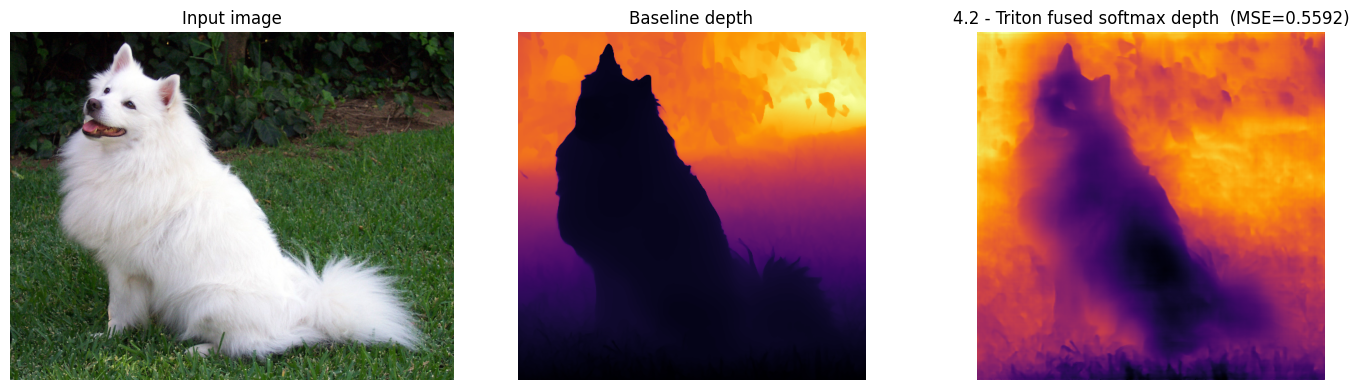

In [ ]:
reset_backends()

try:
    import triton
    import triton.language as tl

    @triton.jit
    def _fused_softmax_kernel(output_ptr, input_ptr, n_cols, BLOCK: tl.constexpr):
        row = tl.program_id(0)
        offsets = tl.arange(0, BLOCK)
        mask = offsets < n_cols
        inp = tl.load(
            input_ptr + row * n_cols + offsets, mask=mask, other=-float("inf")
        )
        row_max = tl.max(inp, axis=0)
        safe = inp - row_max
        num = tl.exp(safe)
        den = tl.sum(num, axis=0)
        out = num / den
        tl.store(output_ptr + row * n_cols + offsets, out, mask=mask)

    class _TritonSoftmax(torch.autograd.Function):
        @staticmethod
        def forward(ctx, x):
            n_cols = x.shape[-1]
            BLOCK = triton.next_power_of_2(n_cols)
            out = torch.empty_like(x)
            _fused_softmax_kernel[(x.numel() // n_cols,)](out, x, n_cols, BLOCK=BLOCK)
            return out

    def _triton_softmax(x, dim=-1):
        if dim != -1 and dim != x.ndim - 1:
            return torch.nn.functional.softmax(x, dim=dim)
        return _TritonSoftmax.apply(x)

    _m = fresh_model()
    # Patch DinoV2 attention blocks
    _patched = 0
    for module in _m.modules():
        if hasattr(module, "attn_drop") and hasattr(module, "qkv"):

            def _make_patched(mod):
                def _fwd(x, **kwargs):  # Accept extra kwargs like pos
                    B, N, C = x.shape
                    qkv = (
                        mod.qkv(x)
                        .reshape(B, N, 3, mod.num_heads, C // mod.num_heads)
                        .permute(2, 0, 3, 1, 4)
                    )
                    q, k, v = qkv.unbind(0)
                    scale = (C // mod.num_heads) ** -0.5
                    attn = (q @ k.transpose(-2, -1)) * scale
                    attn = _triton_softmax(attn, dim=-1)
                    x = (attn @ v).transpose(1, 2).reshape(B, N, C)
                    x = mod.proj(x)
                    if hasattr(mod, "proj_drop") and isinstance(
                        mod.proj_drop, nn.Module
                    ):
                        x = mod.proj_drop(x)
                    return x

                return _fwd

            module.forward = _make_patched(module)
            _patched += 1

    print(f"Patched {_patched} attention blocks with Triton softmax")
    with torch.no_grad():
        _out = _m(dummy_input)
    check_output("triton softmax", _out, baseline_output, atol=0.5)

    bench(
        "4.2 - Triton fused softmax",
        "with torch.no_grad(): model(x)",
        {"model": _m, "x": dummy_input},
    )
except Exception as e:
    print(f"Triton fused softmax failed: {type(e).__name__}: {e}")
    GPU_RESULTS["4.2 - Triton fused softmax"] = float("nan")
cleanup()

---
# §5 – Precision & Quantization

Changing the numeric representation of weights and/or activations.
Lower precision = fewer bytes per element = higher arithmetic throughput.

## 5.1 – AMP FP16

`torch.autocast` selectively casts operations to float16. The backbone
runs in FP16 but DA3's depth head disables autocast by default.


In [ ]:
reset_backends()

bench(
    "5.1 - AMP FP16",
    "with torch.no_grad():\n"
    "  with torch.amp.autocast('cuda', dtype=torch.float16):\n"
    "    model(x)",
    {"model": model, "x": dummy_input},
)

  5.1 - AMP FP16: 114.844 ms  (spread: 0.272 ms  rounds: 114.68, 114.79, 114.95, 114.93, 114.84)  peak VRAM: 4522 MB
  ✓ Sanity (5.1 - AMP FP16): depth MSE = 0.000000


---
### 5.1b – AMP FP16 (patched head)

Patch the depth head to also run under autocast. This removes the FP32
bottleneck in the head's convolutions and activation functions.


In [ ]:
reset_backends()

_m = fresh_model(patch_head_fp16=True)
with torch.no_grad():
    with torch.amp.autocast("cuda", dtype=torch.float16):
        _out = _m(dummy_input)
check_output("AMP FP16 (full)", _out, baseline_output, atol=0.5)

bench(
    "5.1b - AMP FP16 (patched head)",
    "with torch.no_grad():\n"
    "  with torch.amp.autocast('cuda', dtype=torch.float16):\n"
    "    model(x)",
    {"model": _m, "x": dummy_input},
)
cleanup()

[INFO ] using MLP layer as FFN
  [OK] AMP FP16 (full): max diff = 0.000655 (atol=0.5)
  5.1b - AMP FP16 (patched head): 99.801 ms  (spread: 0.056 ms  rounds: 99.82, 99.82, 99.80, 99.77, 99.79)  peak VRAM: 5046 MB
  ✓ Sanity (5.1b - AMP FP16 (patched head)): depth MSE = 0.000000


---
### Profiling: backbone vs head compute split


In [ ]:
#collapse-hide
# ── Profiling: backbone vs head compute split ─────────────────────────────
import torch.utils.benchmark as _b

_net = model.net  # DepthAnything3Net


def _run_backbone():
    with torch.no_grad():
        return _net.backbone(
            dummy_input,
            cam_token=None,
            export_feat_layers=[],
            ref_view_strategy="saddle_balanced",
        )


def _run_head(feats):
    with torch.no_grad():
        with torch.autocast(device_type="cuda", enabled=False):  # DA3's default
            return _net._process_depth_head(feats, 504, 504)


def _run_head_amp(feats):
    with torch.no_grad():
        with torch.amp.autocast("cuda", dtype=torch.float16):  # Allow FP16 in head
            return _net.head(feats, 504, 504, patch_start_idx=0)


def _run_bb_amp():
    with torch.no_grad():
        with torch.amp.autocast("cuda", dtype=torch.float16):
            return _net.backbone(
                dummy_input,
                cam_token=None,
                export_feat_layers=[],
                ref_view_strategy="saddle_balanced",
            )


# Warm up
_feats32 = _run_backbone()[0]
_ = _run_head(_feats32)
_feats16 = _run_bb_amp()[0]
_ = _run_head_amp(_feats16)
torch.cuda.synchronize()

# Measure FP32 components
bb32 = (
    _b.Timer(stmt="f()", globals={"f": _run_backbone})
    .blocked_autorange(min_run_time=3)
    .median
    * 1e3
)
hd32 = (
    _b.Timer(stmt="f(x)", globals={"f": _run_head, "x": _feats32})
    .blocked_autorange(min_run_time=3)
    .median
    * 1e3
)

# Measure AMP FP16 components
bb16 = (
    _b.Timer(stmt="f()", globals={"f": _run_bb_amp})
    .blocked_autorange(min_run_time=3)
    .median
    * 1e3
)
hd16_off = (
    _b.Timer(stmt="f(x)", globals={"f": _run_head, "x": _feats16})
    .blocked_autorange(min_run_time=3)
    .median
    * 1e3
)  # autocast OFF (DA3 default)
hd16_on = (
    _b.Timer(stmt="f(x)", globals={"f": _run_head_amp, "x": _feats16})
    .blocked_autorange(min_run_time=3)
    .median
    * 1e3
)  # autocast ON (patched)

print("=" * 70)
print("COMPONENT PROFILING - backbone vs depth head")
print("=" * 70)
print(f"{'Component':<35} {'FP32':>8} {'AMP FP16':>8} {'Speedup':>8}")
print("-" * 70)
print(f"{'Backbone (DinoV2-L)':<35} {bb32:>7.1f}ms {bb16:>7.1f}ms {bb32 / bb16:>7.2f}x")
print(
    f"{'Head (autocast disabled - DA3 dflt)':<35} {hd32:>7.1f}ms {hd16_off:>7.1f}ms {hd32 / hd16_off:>7.2f}x"
)
print(
    f"{'Head (autocast enabled - patched)':<35} {hd32:>7.1f}ms {hd16_on:>7.1f}ms {hd32 / hd16_on:>7.2f}x"
)
print("-" * 70)
tot32 = bb32 + hd32
tot_cur = bb16 + hd16_off
tot_pat = bb16 + hd16_on
print(
    f"{'E2E current (head FP32)':<35} {tot32:>7.1f}ms {tot_cur:>7.1f}ms {tot32 / tot_cur:>7.2f}x"
)
print(
    f"{'E2E patched (head FP16)':<35} {tot32:>7.1f}ms {tot_pat:>7.1f}ms {tot32 / tot_pat:>7.2f}x"
)
print("=" * 70)
print(f"\nHead fraction of FP32 total: {hd32 / tot32 * 100:.1f}%")
print(f"Head FP16 savings: {hd16_off - hd16_on:.1f} ms")

COMPONENT PROFILING - backbone vs depth head
Component                               FP32 AMP FP16  Speedup
----------------------------------------------------------------------
Backbone (DinoV2-L)                   124.3ms    64.4ms    1.93x
Head (autocast disabled - DA3 dflt)    48.9ms    48.9ms    1.00x
Head (autocast enabled - patched)      48.9ms    31.7ms    1.54x
----------------------------------------------------------------------
E2E current (head FP32)               173.2ms   113.4ms    1.53x
E2E patched (head FP16)               173.2ms    96.2ms    1.80x

Head fraction of FP32 total: 28.2%
Head FP16 savings: 17.2 ms


---
## 5.2 – AMP BF16

BFloat16 has the same exponent range as FP32 but only 8 mantissa bits.
Natively supported on Ampere+; emulated (slower) on older architectures.


In [ ]:
reset_backends()

if not torch.cuda.is_bf16_supported():
    print("BF16 not supported on this GPU - skipping")
    GPU_RESULTS["5.2 - AMP BF16"] = float("nan")
else:
    bench(
        "5.2 - AMP BF16",
        "with torch.no_grad():\n"
        "  with torch.amp.autocast('cuda', dtype=torch.bfloat16):\n"
        "    model(x)",
        {"model": model, "x": dummy_input},
    )

  5.2 - AMP BF16: 250.300 ms  (spread: 0.533 ms  rounds: 250.06, 250.60, 250.21, 250.30, 250.33)  peak VRAM: 4696 MB
  ✓ Sanity (5.2 - AMP BF16): depth MSE = 0.000000


---
## 5.3 – Static FP16 (`model.half()`)

Convert all weights to FP16 permanently. No autocast dispatching overhead —
every operation runs in half precision from the start.


In [ ]:
reset_backends()

# Static FP16: DA3 has multiple forced-float32 paths (pos embed, cam_dec).
# Use fullgraph forward + pos embed patch to stay fully in float16.
try:
    _m = fresh_model(patch_head_fp16=True, fullgraph=True).half()
    _x = dummy_input.half()
    with torch.no_grad():
        _out = _m(_x)
    check_output("static fp16", _out, baseline_output, atol=0.5)
    bench("5.3 - Static FP16", "with torch.no_grad(): model(x)", {"model": _m, "x": _x})
except RuntimeError:
    import traceback

    traceback.print_exc()
    GPU_RESULTS["5.3 - Static FP16"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
  Fullgraph forward patched: addict.Dict bypassed
  [OK] static fp16: max diff = 0.000580 (atol=0.5)
  5.3 - Static FP16: 88.489 ms  (spread: 0.076 ms  rounds: 88.49, 88.52, 88.51, 88.49, 88.44)  peak VRAM: 4753 MB
  ✓ Sanity (5.3 - Static FP16): depth MSE = 0.000000


---
## 5.4 – torchao int8 weight-only

Quantize weights to 8-bit integers while keeping activations in FP32.
De-quantization happens at matmul time (weight × scale → fp32).


In [ ]:
reset_backends()

try:
    from torchao.quantization import quantize_, int8_weight_only

    _m = fresh_model()
    quantize_(_m, int8_weight_only())
    with torch.no_grad():
        _out = _m(dummy_input)
    check_output("torchao int8wo", _out, baseline_output, atol=1.0)

    bench(
        "5.4 - torchao int8 weight-only",
        "with torch.no_grad(): model(x)",
        {"model": _m, "x": dummy_input},
    )
except Exception as e:
    print(f"torchao int8 weight-only failed: {e}")
    GPU_RESULTS["5.4 - torchao int8 weight-only"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
  [OK] torchao int8wo: max diff = 0.002511 (atol=1.0)
  5.4 - torchao int8 weight-only: 186.669 ms  (spread: 0.847 ms  rounds: 186.21, 186.80, 186.67, 186.57, 187.06)  peak VRAM: 3843 MB
  ✓ Sanity (5.4 - torchao int8 weight-only): depth MSE = 0.000005


---
## 5.5 – torchao int8 dynamic

Quantize both weights and activations to int8 dynamically. Per-token
activation scales computed on-the-fly. Stronger compression but may
be slower due to quantization overhead.


In [ ]:
reset_backends()

try:
    from torchao.quantization import quantize_, int8_dynamic_activation_int8_weight

    _m = fresh_model()
    quantize_(_m, int8_dynamic_activation_int8_weight())
    with torch.no_grad():
        _out = _m(dummy_input)
    check_output("torchao int8dyn", _out, baseline_output, atol=1.0)

    bench(
        "5.5 - torchao int8 dynamic",
        "with torch.no_grad(): model(x)",
        {"model": _m, "x": dummy_input},
    )
except Exception as e:
    print(f"torchao int8 dynamic failed: {e}")
    GPU_RESULTS["5.5 - torchao int8 dynamic"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
  [OK] torchao int8dyn: max diff = 0.009104 (atol=1.0)
  5.5 - torchao int8 dynamic: 371.858 ms  (spread: 0.668 ms  rounds: 371.60, 372.19, 371.82, 371.86, 372.26)  peak VRAM: 3403 MB
  ✓ Sanity (5.5 - torchao int8 dynamic): depth MSE = 0.000020


---
## 5.6 – torchao int4 weight-only

4-bit weight quantization via custom Triton kernels. 4× memory reduction
but requires `TensorCoreTiledLayout` (SM ≥ 8.0, Ampere+).


In [ ]:
reset_backends()

try:
    from torchao.quantization import quantize_, int4_weight_only

    cap = torch.cuda.get_device_capability()
    if cap < (8, 0):
        print(
            f"GPU SM {cap[0]}.{cap[1]}: int4 TensorCoreTiledLayout requires SM >= 8.0 (Ampere+).\n"
            "  This GPU does not have the required int4 Tensor Core instructions.\n"
            "  Skipping - this optimization is Ampere/Hopper only."
        )
        GPU_RESULTS["5.6 - torchao int4 weight-only"] = float("nan")
    else:
        _m = fresh_model()
        quantize_(_m, int4_weight_only())
        _x = dummy_input.to(_m.net.backbone.pretrained.cls_token.dtype)
        with torch.no_grad():
            _out = _m(_x)
        check_output("torchao int4wo", _out, baseline_output, atol=2.0)

        bench(
            "5.6 - torchao int4 weight-only",
            "with torch.no_grad(): model(x)",
            {"model": _m, "x": _x},
        )
except Exception as e:
    print(f"torchao int4 weight-only failed: {type(e).__name__}: {e}")
    GPU_RESULTS["5.6 - torchao int4 weight-only"] = float("nan")
cleanup()

GPU SM 7.0: int4 TensorCoreTiledLayout requires SM >= 8.0 (Ampere+).
  This GPU does not have the required int4 Tensor Core instructions.
  Skipping - this optimization is Ampere/Hopper only.


---
## 5.7 – bitsandbytes int8 (LLM.int8())

Absmax int8 quantization from the LLM.int8() paper. Keeps outlier features
in FP16 via mixed-precision decomposition.


In [ ]:
reset_backends()

try:
    import bitsandbytes as bnb

    _m = fresh_model()

    # Replace Linear layers with bnb.nn.Linear8bitLt
    def _replace_with_bnb_int8(module):
        for name, child in module.named_children():
            if isinstance(child, nn.Linear):
                has_bias = child.bias is not None
                new = bnb.nn.Linear8bitLt(
                    child.in_features,
                    child.out_features,
                    bias=has_bias,
                    has_fp16_weights=False,
                    threshold=6.0,
                )
                new.weight = bnb.nn.Int8Params(
                    child.weight.data,
                    requires_grad=False,
                    has_fp16_weights=False,
                )
                if has_bias:
                    new.bias = nn.Parameter(child.bias.data)
                setattr(module, name, new.to(device))
            else:
                _replace_with_bnb_int8(child)

    _replace_with_bnb_int8(_m)
    _m = _m.to(device).eval()

    with torch.no_grad():
        _out = _m(dummy_input)
    check_output("bnb int8", _out, baseline_output, atol=2.0)

    bench(
        "5.7 - bitsandbytes int8",
        "with torch.no_grad(): model(x)",
        {"model": _m, "x": dummy_input},
    )
except Exception as e:
    print(f"bitsandbytes int8 failed: {type(e).__name__}: {e}")
    GPU_RESULTS["5.7 - bitsandbytes int8"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
  [OK] bnb int8: max diff = 0.004391 (atol=2.0)
  5.7 - bitsandbytes int8: 225.710 ms  (spread: 0.158 ms  rounds: 225.62, 225.71, 225.74, 225.61, 225.77)  peak VRAM: 3548 MB
  ✓ Sanity (5.7 - bitsandbytes int8): depth MSE = 0.000024


---
## 5.8 – bitsandbytes NF4

4-bit NormalFloat from the QLoRA paper. Information-theoretically optimal
for normally-distributed weights.


In [ ]:
reset_backends()

try:
    import bitsandbytes as bnb

    _m = fresh_model()

    def _replace_with_bnb_nf4(module):
        for name, child in module.named_children():
            if isinstance(child, nn.Linear):
                has_bias = child.bias is not None
                new = bnb.nn.LinearNF4(
                    child.in_features,
                    child.out_features,
                    bias=has_bias,
                )
                new.weight = bnb.nn.Params4bit(
                    child.weight.data,
                    requires_grad=False,
                    quant_type="nf4",
                    blocksize=64,
                )
                if has_bias:
                    new.bias = nn.Parameter(child.bias.data)
                setattr(module, name, new.to(device))
            else:
                _replace_with_bnb_nf4(child)

    _replace_with_bnb_nf4(_m)
    _m = _m.to(device).eval()

    with torch.no_grad():
        _out = _m(dummy_input)
    check_output("bnb nf4", _out, baseline_output, atol=5.0)

    bench(
        "5.8 - bitsandbytes NF4",
        "with torch.no_grad(): model(x)",
        {"model": _m, "x": dummy_input},
    )
except Exception as e:
    print(f"bitsandbytes NF4 failed: {type(e).__name__}: {e}")
    GPU_RESULTS["5.8 - bitsandbytes NF4"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
  [OK] bnb nf4: max diff = 0.020788 (atol=5.0)
  5.8 - bitsandbytes NF4: 178.090 ms  (spread: 0.526 ms  rounds: 177.76, 178.09, 177.90, 178.16, 178.28)  peak VRAM: 2838 MB
  ✓ Sanity (5.8 - bitsandbytes NF4): depth MSE = 0.000475


---
# §6 – ONNX Runtime

Export the model to ONNX format and run inference through ORT's optimized
graph execution engine.

## 6.1 – ONNX export + ORT CUDA EP

Export via `torch.onnx.export`, then run with ORT's CUDA execution provider.
ORT applies graph-level optimizations (constant folding, operator fusion).


In [ ]:
reset_backends()

try:
    import onnxruntime as ort
    from torch.onnx import register_custom_op_symbolic
    import torch.onnx.symbolic_helper as sym_help

    # Register ONNX symbolic for aten::cartesian_prod (used by DA3 RoPE).
    # Implements: cartesian_prod(a, b) → meshgrid-style (N*M, 2) output.
    def _cartesian_prod_onnx(g, tensor_list):
        tensors = sym_help._unpack_list(tensor_list)
        if len(tensors) != 2:
            return sym_help._unimplemented("cartesian_prod", "only 2 inputs")
        a, b = tensors
        a_shape = g.op("Shape", a)
        b_shape = g.op("Shape", b)
        one = g.op("Constant", value_t=torch.tensor([1], dtype=torch.int64))
        neg1 = g.op("Constant", value_t=torch.tensor([-1], dtype=torch.int64))
        axes_0 = g.op("Constant", value_t=torch.tensor([0], dtype=torch.int64))
        axes_1 = g.op("Constant", value_t=torch.tensor([1], dtype=torch.int64))
        a_2d = g.op("Reshape", a, g.op("Concat", a_shape, one, axis_i=0))
        target = g.op("Concat", a_shape, b_shape, axis_i=0)
        a_flat = g.op("Reshape", g.op("Expand", a_2d, target), neg1)
        b_2d = g.op("Reshape", b, g.op("Concat", one, b_shape, axis_i=0))
        b_flat = g.op("Reshape", g.op("Expand", b_2d, target), neg1)
        # Opset 13+: Unsqueeze takes axes as second input, not attribute
        a_col = g.op("Unsqueeze", a_flat, axes_1)
        b_col = g.op("Unsqueeze", b_flat, axes_1)
        return g.op("Concat", a_col, b_col, axis_i=1)

    register_custom_op_symbolic("aten::cartesian_prod", _cartesian_prod_onnx, 17)

    _m = fresh_model()

    with timed("ONNX export"):
        torch.onnx.export(
            _m,
            dummy_input,
            "model.onnx",
            input_names=["input"],
            output_names=["depth"],
            dynamic_axes={"input": {0: "batch"}, "depth": {0: "batch"}},
            opset_version=17,
        )

    with timed("ORT session"):
        opts = ort.SessionOptions()
        opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_EXTENDED
        sess = ort.InferenceSession(
            "model.onnx",
            opts,
            providers=["CUDAExecutionProvider", "CPUExecutionProvider"],
        )

    _np_input = dummy_input.cpu().numpy()
    _ort_out = sess.run(None, {"input": _np_input})[0]
    check_output(
        "ORT CUDA", torch.tensor(_ort_out).to(device), baseline_output, atol=0.5
    )

    bench(
        "6.1 - ORT CUDA EP",
        "sess.run(None, {'input': np_input})",
        {"sess": sess, "np_input": _np_input},
        sanity=False,
    )
except Exception as e:
    print(f"ORT CUDA EP failed: {type(e).__name__}: {e}")
    GPU_RESULTS["6.1 - ORT CUDA EP"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
  [ONNX export] setup: 13.13 s


2026-03-30 20:34:49.883944738 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 81 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.
2026-03-30 20:34:52.523292092 [W:onnxruntime:Default, scatter_nd.h:51 ScatterNDWithAtomicReduction] ScatterND with reduction=='none' only guarantees to be correct if indices are not duplicated.


  [ORT session] setup: 4.96 s
  [OK] ORT CUDA: max diff = 0.000000 (atol=0.5)
  6.1 - ORT CUDA EP: 130.111 ms  (spread: 0.191 ms  rounds: 130.07, 129.96, 130.11, 130.15, 130.15)  peak VRAM: 3499 MB


---
## 6.2 – ORT CUDA EP + IO Binding

Keep input/output tensors on GPU. Eliminates host↔device copies that
the default `sess.run()` API introduces.


In [ ]:
reset_backends()

try:
    import onnxruntime as ort

    if not os.path.exists("model.onnx"):
        print("model.onnx not found - run cell 17 first")
        GPU_RESULTS["6.2 - ORT IO Binding"] = float("nan")
    else:
        opts = ort.SessionOptions()
        opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_EXTENDED
        sess = ort.InferenceSession(
            "model.onnx", opts, providers=["CUDAExecutionProvider"]
        )

        _io = sess.io_binding()
        _gpu_input = dummy_input.contiguous()
        _gpu_output = torch.empty_like(baseline_output)
        _io.bind_input(
            "input",
            "cuda",
            0,
            np.float32,
            list(_gpu_input.shape),
            _gpu_input.data_ptr(),
        )
        _io.bind_output(
            "depth",
            "cuda",
            0,
            np.float32,
            list(_gpu_output.shape),
            _gpu_output.data_ptr(),
        )

        sess.run_with_iobinding(_io)
        check_output("ORT IO Bind", _gpu_output, baseline_output, atol=0.5)

        bench(
            "6.2 - ORT IO Binding",
            "sess.run_with_iobinding(io)",
            {"sess": sess, "io": _io},
            sanity=False,
        )
except Exception as e:
    print(f"ORT IO Binding failed: {type(e).__name__}: {e}")
    GPU_RESULTS["6.2 - ORT IO Binding"] = float("nan")
cleanup()

2026-03-30 20:36:04.852254361 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 81 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.
2026-03-30 20:36:04.890020634 [W:onnxruntime:, session_state.cc:1327 VerifyEachNodeIsAssignedToAnEp] Some nodes were not assigned to the preferred execution providers which may or may not have an negative impact on performance. e.g. ORT explicitly assigns shape related ops to CPU to improve perf.
2026-03-30 20:36:04.890032836 [W:onnxruntime:, session_state.cc:1329 VerifyEachNodeIsAssignedToAnEp] Rerunning with verbose output on a non-minimal build will show node assignments.
2026-03-30 20:36:07.464938672 [W:onnxruntime:Default, scatter_nd.h:51 ScatterNDWithAtomicReduction] ScatterND with reduction=='none' only guarantees to be correct if indices are not duplicate

  [OK] ORT IO Bind: max diff = 0.000000 (atol=0.5)
  6.2 - ORT IO Binding: 129.180 ms  (spread: 0.253 ms  rounds: 129.38, 129.18, 129.21, 129.14, 129.12)  peak VRAM: 3500 MB


---
## 6.3 – ONNX Optimize + Simplify + ORT

Apply `onnxoptimizer` passes and `onnxsim` shape-inference simplification
before ORT. This reduces the graph from ~5000 to ~3900 nodes.


In [ ]:
reset_backends()

try:
    import onnxruntime as ort

    if not os.path.exists("model.onnx"):
        print("model.onnx not found - run cell 17 first")
        GPU_RESULTS["6.3 - ORT optimized+simplified"] = float("nan")
    else:
        import onnx
        import onnxoptimizer
        from onnxsim import simplify as onnxsim_simplify

        with timed("ONNX optimize + simplify"):
            _model = onnx.load("model.onnx")
            # onnxoptimizer: constant folding, dead code, operator fusion
            _passes = onnxoptimizer.get_fuse_and_elimination_passes()
            _model = onnxoptimizer.optimize(_model, _passes)
            n_before = len(_model.graph.node)
            # onnxsim: shape inference + further simplification
            _model, _ok = onnxsim_simplify(_model)
            n_after = len(_model.graph.node)
            onnx.save(_model, "model_opt.onnx")
            _sz_orig = os.path.getsize("model.onnx") / 1e6
            _sz_opt = os.path.getsize("model_opt.onnx") / 1e6
            print(f"  Nodes: {n_before} → {n_after}  "
                  f"Size: {_sz_orig:.1f} → {_sz_opt:.1f} MB  "
                  f"simplified: {_ok}")

        opts = ort.SessionOptions()
        opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_EXTENDED
        sess = ort.InferenceSession(
            "model_opt.onnx", opts,
            providers=["CUDAExecutionProvider", "CPUExecutionProvider"],
        )
        _input_name = sess.get_inputs()[0].name
        _np_input = dummy_input.cpu().numpy()
        _ort_out = sess.run(None, {_input_name: _np_input})[0]
        check_output("ORT optimized", torch.tensor(_ort_out).to(device),
                      baseline_output, atol=0.5)

        bench(
            "6.3 - ORT optimized+simplified",
            "sess.run(None, {input_name: np_input})",
            {"sess": sess, "np_input": _np_input, "input_name": _input_name},
            sanity=False,
        )
except Exception as e:
    print(f"ORT optimized+simplified failed: {type(e).__name__}: {e}")
    GPU_RESULTS["6.3 - ORT optimized+simplified"] = float("nan")
cleanup()

  Nodes: 4936 → 3899  Size: 1349.4 → 1348.9 MB  simplified: True
  [ONNX optimize + simplify] setup: 128.15 s


2026-03-30 20:39:28.328086764 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 77 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.
2026-03-30 20:39:30.150631661 [W:onnxruntime:Default, scatter_nd.h:51 ScatterNDWithAtomicReduction] ScatterND with reduction=='none' only guarantees to be correct if indices are not duplicated.


  [OK] ORT optimized: max diff = 0.000000 (atol=0.5)
  6.3 - ORT optimized+simplified: 129.777 ms  (spread: 0.324 ms  rounds: 129.63, 129.75, 129.78, 129.91, 129.95)  peak VRAM: 3500 MB


---
# §7 – TensorRT

NVIDIA's inference optimizer. Fuses layers, selects hardware-optimal kernels,
and applies precision calibration. TRT 8.6 supports SM ≥ 5.3 (Maxwell+).

## 7.1 – TRT 8.6 Native FP16

Build a TensorRT engine from the ONNX graph with FP16 precision enabled.
GraphSurgeon cleans up the graph first (constant folding, dead code removal).


In [ ]:
reset_backends()

try:
    import tensorrt as trt

    # onnx-graphsurgeon 0.5.x references onnx.helper.float32_to_bfloat16
    # which was removed in onnx >= 1.20. Patch it back:
    import struct, onnx.helper
    if not hasattr(onnx.helper, "float32_to_bfloat16"):
        def _f32_to_bf16(fval):
            return (struct.unpack("I", struct.pack("f", fval))[0] >> 16) & 0xFFFF
        onnx.helper.float32_to_bfloat16 = _f32_to_bf16

    import onnx_graphsurgeon as gs

    _onnx_path = "model_opt.onnx" if os.path.exists("model_opt.onnx") else "model.onnx"
    if not os.path.exists(_onnx_path):
        raise FileNotFoundError("Export ONNX first (cell 17)")

    # ── GraphSurgeon: fold constants, remove identity ops ────────────────
    with timed("GraphSurgeon cleanup"):
        _graph = gs.import_onnx(onnx.load(_onnx_path))
        _graph.fold_constants()
        _graph.cleanup()
        _graph.toposort()
        _gs_model = gs.export_onnx(_graph)
        onnx.save(_gs_model, "model_gs.onnx")
        print(f"  GraphSurgeon: {len(_graph.nodes)} nodes after cleanup")

    # ── Build TRT 8.6 FP16 engine ───────────────────────────────────────
    TRT_LOGGER = trt.Logger(trt.Logger.WARNING)
    with timed("TRT 8.6 FP16 engine build"):
        builder = trt.Builder(TRT_LOGGER)
        network = builder.create_network(
            1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH)
        )
        parser = trt.OnnxParser(network, TRT_LOGGER)
        with open("model_gs.onnx", "rb") as f:
            if not parser.parse(f.read()):
                for i in range(parser.num_errors):
                    print(f"  TRT parse error: {parser.get_error(i)}")
                raise RuntimeError("TRT ONNX parse failed")

        config = builder.create_builder_config()
        config.set_memory_pool_limit(trt.MemoryPoolType.WORKSPACE, 4 << 30)  # 4 GB
        config.set_flag(trt.BuilderFlag.FP16)

        # The ONNX model has dynamic batch + output dims → add optimization profile
        _trt_profile = builder.create_optimization_profile()
        # Input: (batch, 1, 3, 504, 504)
        _in_name = network.get_input(0).name
        _trt_profile.set_shape(_in_name, (1, 1, 3, IMG_SIZE, IMG_SIZE),
                               (1, 1, 3, IMG_SIZE, IMG_SIZE),
                               (1, 1, 3, IMG_SIZE, IMG_SIZE))
        config.add_optimization_profile(_trt_profile)

        engine_bytes = builder.build_serialized_network(network, config)
        if engine_bytes is None:
            raise RuntimeError("TRT engine build returned None")
        runtime = trt.Runtime(TRT_LOGGER)
        engine = runtime.deserialize_cuda_engine(engine_bytes)

    # ── Allocate buffers & benchmark ─────────────────────────────────────
    context = engine.create_execution_context()
    # Set input shape for the dynamic profile
    context.set_input_shape(engine.get_tensor_name(0), dummy_input.shape)

    _d_input = torch.empty_like(dummy_input, device=device).contiguous()
    _d_output = torch.empty_like(baseline_output, device=device).contiguous()

    def _trt_infer():
        _d_input.copy_(dummy_input)
        context.set_tensor_address(engine.get_tensor_name(0), _d_input.data_ptr())
        context.set_tensor_address(engine.get_tensor_name(1), _d_output.data_ptr())
        context.execute_async_v3(stream_handle=torch.cuda.current_stream().cuda_stream)
        torch.cuda.synchronize()

    _trt_infer()
    check_output("TRT 8.6 FP16", _d_output, baseline_output, atol=0.5)

    bench(
        "7.1 - TRT 8.6 FP16",
        "fn()",
        {"fn": _trt_infer},
        sanity=False,
    )
except ImportError as e:
    print(f"TensorRT 8.6.1 or GraphSurgeon not available: {e}")
    GPU_RESULTS["7.1 - TRT 8.6 FP16"] = float("nan")
except Exception as e:
    print(f"TRT 8.6 FP16 failed: {type(e).__name__}: {e}")
    GPU_RESULTS["7.1 - TRT 8.6 FP16"] = float("nan")
cleanup()

  GraphSurgeon: 3899 nodes after cleanup
  [GraphSurgeon cleanup] setup: 9.83 s


[libprotobuf WARNING google/protobuf/io/coded_stream.cc:604] Reading dangerously large protocol message.  If the message turns out to be larger than 2147483647 bytes, parsing will be halted for security reasons.  To increase the limit (or to disable these warnings), see CodedInputStream::SetTotalBytesLimit() in google/protobuf/io/coded_stream.h.
[libprotobuf WARNING google/protobuf/io/coded_stream.cc:81] The total number of bytes read was 1348905296


[03/30/2026-20:40:29] [TRT] [W] onnx2trt_utils.cpp:374: Your ONNX model has been generated with INT64 weights, while TensorRT does not natively support INT64. Attempting to cast down to INT32.
[03/30/2026-20:40:29] [TRT] [W] onnx2trt_utils.cpp:400: One or more weights outside the range of INT32 was clamped
[03/30/2026-20:47:53] [TRT] [W] TensorRT encountered issues when converting weights between types and that could affect accuracy.
[03/30/2026-20:47:53] [TRT] [W] If this is not the desired behavior, please modify the weights or retrain with regularization to adjust the magnitude of the weights.
[03/30/2026-20:47:53] [TRT] [W] Check verbose logs for the list of affected weights.
[03/30/2026-20:47:53] [TRT] [W] - 254 weights are affected by this issue: Detected subnormal FP16 values.
[03/30/2026-20:47:53] [TRT] [W] - 112 weights are affected by this issue: Detected values less than smallest positive FP16 subnormal value and converted them to the FP16 minimum subnormalized value.
  [TRT

---
## 7.2 – TRT 8.6 INT8 (calibrated)

Post-training INT8 quantization with entropy calibration. TRT profiles
activation ranges from representative inputs to compute per-tensor scales.

> **Note:** INT8 Tensor Core throughput on Volta is limited compared to
> Ampere/Hopper. Many layers fall back to FP16 when INT8 kernels aren't
> available, yielding marginal gains over pure FP16.


In [ ]:
reset_backends()

try:
    import tensorrt as trt

    _onnx_path = "model_gs.onnx" if os.path.exists("model_gs.onnx") else "model.onnx"
    if not os.path.exists(_onnx_path):
        raise FileNotFoundError("Export ONNX first (cell 17) and run 19c for GraphSurgeon")

    # ── INT8 Calibrator using PyTorch CUDA tensors ───────────────────────
    class _EntropyCalibrator(trt.IInt8EntropyCalibrator2):
        """Feeds calibration data to TRT via torch CUDA tensors."""

        def __init__(self, data_tensor: torch.Tensor, cache_file="trt_int8.cache"):
            super().__init__()
            self.data = data_tensor  # (N, ...) on CPU
            self.current_index = 0
            self.cache_file = cache_file
            self.device_buf = self.data[0:1].cuda().contiguous()

        def get_batch_size(self):
            return 1

        def get_batch(self, names):
            if self.current_index >= len(self.data):
                return None
            self.device_buf.copy_(self.data[self.current_index : self.current_index + 1])
            self.current_index += 1
            return [self.device_buf.data_ptr()]

        def read_calibration_cache(self):
            if os.path.exists(self.cache_file):
                with open(self.cache_file, "rb") as f:
                    return f.read()
            return None

        def write_calibration_cache(self, cache):
            with open(self.cache_file, "wb") as f:
                f.write(cache)

    # Generate calibration data (8 random inputs + real test image)
    _calib_data = torch.randn(8, 1, 3, IMG_SIZE, IMG_SIZE)
    _calib_data[0] = SANITY_INPUT.cpu()
    calibrator = _EntropyCalibrator(_calib_data)

    # ── Build TRT INT8 engine ────────────────────────────────────────────
    TRT_LOGGER = trt.Logger(trt.Logger.WARNING)
    with timed("TRT 8.6 INT8 engine build"):
        builder = trt.Builder(TRT_LOGGER)
        network = builder.create_network(
            1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH)
        )
        parser = trt.OnnxParser(network, TRT_LOGGER)
        with open(_onnx_path, "rb") as f:
            if not parser.parse(f.read()):
                for i in range(parser.num_errors):
                    print(f"  TRT parse error: {parser.get_error(i)}")
                raise RuntimeError("TRT ONNX parse failed")

        config = builder.create_builder_config()
        config.set_memory_pool_limit(trt.MemoryPoolType.WORKSPACE, 4 << 30)
        config.set_flag(trt.BuilderFlag.FP16)
        config.set_flag(trt.BuilderFlag.INT8)
        config.int8_calibrator = calibrator

        # Add optimization profile for dynamic shapes
        _trt_profile = builder.create_optimization_profile()
        _in_name = network.get_input(0).name
        _trt_profile.set_shape(_in_name, (1, 1, 3, IMG_SIZE, IMG_SIZE),
                               (1, 1, 3, IMG_SIZE, IMG_SIZE),
                               (1, 1, 3, IMG_SIZE, IMG_SIZE))
        config.add_optimization_profile(_trt_profile)

        engine_bytes = builder.build_serialized_network(network, config)
        if engine_bytes is None:
            raise RuntimeError("TRT INT8 engine build returned None")
        runtime = trt.Runtime(TRT_LOGGER)
        engine = runtime.deserialize_cuda_engine(engine_bytes)

    context = engine.create_execution_context()
    context.set_input_shape(engine.get_tensor_name(0), dummy_input.shape)

    _d_input = torch.empty_like(dummy_input, device=device).contiguous()
    _d_output = torch.empty_like(baseline_output, device=device).contiguous()

    def _trt_int8_infer():
        _d_input.copy_(dummy_input)
        context.set_tensor_address(engine.get_tensor_name(0), _d_input.data_ptr())
        context.set_tensor_address(engine.get_tensor_name(1), _d_output.data_ptr())
        context.execute_async_v3(stream_handle=torch.cuda.current_stream().cuda_stream)
        torch.cuda.synchronize()

    _trt_int8_infer()
    check_output("TRT 8.6 INT8", _d_output, baseline_output, atol=1.0)

    bench(
        "7.2 - TRT 8.6 INT8",
        "fn()",
        {"fn": _trt_int8_infer},
        sanity=False,
    )
except ImportError:
    print("TensorRT 8.6.1 not available — skipping")
    GPU_RESULTS["7.2 - TRT 8.6 INT8"] = float("nan")
except Exception as e:
    print(f"TRT 8.6 INT8 failed: {type(e).__name__}: {e}")
    GPU_RESULTS["7.2 - TRT 8.6 INT8"] = float("nan")
cleanup()

[libprotobuf WARNING google/protobuf/io/coded_stream.cc:604] Reading dangerously large protocol message.  If the message turns out to be larger than 2147483647 bytes, parsing will be halted for security reasons.  To increase the limit (or to disable these warnings), see CodedInputStream::SetTotalBytesLimit() in google/protobuf/io/coded_stream.h.
[libprotobuf WARNING google/protobuf/io/coded_stream.cc:81] The total number of bytes read was 1348905296


[03/30/2026-20:48:26] [TRT] [W] onnx2trt_utils.cpp:374: Your ONNX model has been generated with INT64 weights, while TensorRT does not natively support INT64. Attempting to cast down to INT32.
[03/30/2026-20:48:26] [TRT] [W] onnx2trt_utils.cpp:400: One or more weights outside the range of INT32 was clamped
[03/30/2026-20:48:27] [TRT] [W] Missing scale and zero-point for tensor (Unnamed Layer* 2) [Constant]_output, expect fall back to non-int8 implementation for any layer consuming or producing given tensor
[03/30/2026-20:48:27] [TRT] [W] Missing scale and zero-point for tensor (Unnamed Layer* 16) [Constant]_output, expect fall back to non-int8 implementation for any layer consuming or producing given tensor
[03/30/2026-20:48:27] [TRT] [W] Missing scale and zero-point for tensor /net/backbone/Cast_11_output_0, expect fall back to non-int8 implementation for any layer consuming or producing given tensor
[03/30/2026-20:48:27] [TRT] [W] Missing scale and zero-point for tensor (Unnamed Laye

---
## 7.3 – ORT TensorRT EP

Run TRT through ONNX Runtime's TensorRT execution provider.
Requires matching TRT shared libraries in `LD_LIBRARY_PATH`.


In [ ]:
reset_backends()

try:
    import onnxruntime as ort

    if "TensorrtExecutionProvider" not in ort.get_available_providers():
        print("TensorRT EP not available")
        GPU_RESULTS["7.3 - ORT TensorRT EP"] = float("nan")
    elif not os.path.exists("model.onnx"):
        print("model.onnx not found - run cell 17 first")
        GPU_RESULTS["7.3 - ORT TensorRT EP"] = float("nan")
    else:
        # TensorRT EP requires shape inference on the ONNX model first
        import onnx
        from onnx import shape_inference

        with timed("ONNX shape inference"):
            _onnx_model = onnx.load("model.onnx")
            _onnx_model = shape_inference.infer_shapes(_onnx_model)
            onnx.save(_onnx_model, "model_prep.onnx")

        with timed("TRT engine build"):
            sess = ort.InferenceSession(
                "model_prep.onnx",
                providers=["TensorrtExecutionProvider", "CUDAExecutionProvider"],
            )
        _input_name = sess.get_inputs()[0].name
        _np_in = dummy_input.cpu().numpy()
        _out = sess.run(None, {_input_name: _np_in})[0]
        check_output(
            "ORT TRT", torch.tensor(_out).to(device), baseline_output, atol=1.0
        )
        bench(
            "7.3 - ORT TensorRT EP",
            "sess.run(None, {input_name: np_input})",
            {"sess": sess, "np_input": _np_in, "input_name": _input_name},
            sanity=False,
        )
except Exception as e:
    print(f"ORT TensorRT EP failed: {type(e).__name__}: {e}")
    GPU_RESULTS["7.3 - ORT TensorRT EP"] = float("nan")
cleanup()

  [ONNX shape inference] setup: 12.83 s
*************** EP Error ***************
EP Error /onnxruntime_src/onnxruntime/python/onnxruntime_pybind_state.cc:539 void onnxruntime::python::RegisterTensorRTPluginsAsCustomOps(PySessionOptions&, const onnxruntime::ProviderOptions&) Please install TensorRT libraries as mentioned in the GPU requirements page, make sure they're in the PATH or LD_LIBRARY_PATH, and that your GPU is supported.
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
****************************************


2026-03-30 20:56:56.838978460 [E:onnxruntime:Default, provider_bridge_ort.cc:2331 TryGetProviderInfo_TensorRT] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1952 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /root/nn_inference/.venv/lib/python3.11/site-packages/onnxruntime/capi/libonnxruntime_providers_tensorrt.so with error: libnvinfer.so.10: cannot open shared object file: No such file or directory

2026-03-30 20:56:59.193200804 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 81 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.
2026-03-30 20:57:01.048796325 [W:onnxruntime:Default, scatter_nd.h:51 ScatterNDWithAtomicReduction] ScatterND with reduction=='none' only guarantees to be correct if indices are n

  [TRT engine build] setup: 4.25 s
  [OK] ORT TRT: max diff = 0.000000 (atol=1.0)
  7.3 - ORT TensorRT EP: 129.623 ms  (spread: 0.189 ms  rounds: 129.65, 129.47, 129.57, 129.62, 129.66)  peak VRAM: 3507 MB


---
## 7.4 – Torch-TensorRT

Direct TRT compilation from PyTorch via `torch_tensorrt`.
Requires Turing architecture or later (SM ≥ 7.5).


In [ ]:
reset_backends()

try:
    import torch_tensorrt

    cap = torch.cuda.get_device_capability()
    if cap < (7, 5):
        print(
            f"GPU SM {cap[0]}.{cap[1]}: torch-tensorrt (TRT 10.x) requires "
            "Turing architecture or later (SM >= 7.5). Skipping."
        )
        GPU_RESULTS["7.4 - Torch-TensorRT"] = float("nan")
    else:
        _m = fresh_model(patch_head_fp16=True, patch_rope=True, fullgraph=True).half()
        _x16 = dummy_input.half()
        with timed("Torch-TRT compile"):
            _trt = torch_tensorrt.compile(
                _m,
                inputs=[torch_tensorrt.Input(shape=list(dummy_input.shape), dtype=torch.float16)],
                enabled_precisions={torch.float16},
            )
        with torch.no_grad():
            _out = _trt(_x16)
        check_output("Torch-TRT", _out, baseline_output, atol=1.0)
        bench(
            "7.4 - Torch-TensorRT",
            "with torch.no_grad(): model(x)",
            {"model": _trt, "x": _x16},
        )
except Exception as e:
    print(f"Torch-TRT failed: {type(e).__name__}: {e}")
    GPU_RESULTS["7.4 - Torch-TensorRT"] = float("nan")
cleanup()

Torch-TRT failed: ModuleNotFoundError: No module named 'torch_tensorrt'


---
# §8 – Graph Capture & Export

Capture the full execution graph and replay it, eliminating Python overhead
and enabling kernel scheduling optimizations.

## 8.1 – JIT Trace

`torch.jit.trace` records operations from a sample input. The resulting
TorchScript graph gets `optimize_for_inference` pass (BatchNorm fusion, etc.).


In [ ]:
reset_backends()

_m = fresh_model()
try:
    with torch.no_grad():
        _traced = torch.jit.trace(_m, dummy_input)
    _traced = torch.jit.optimize_for_inference(_traced)
    with torch.no_grad():
        _out = _traced(dummy_input)
    check_output("jit trace", _out, baseline_output, atol=0.5)
    bench(
        "8.1 - JIT Trace",
        "with torch.no_grad(): model(x)",
        {"model": _traced, "x": dummy_input},
    )
except Exception as e:
    print(f"JIT Trace failed: {type(e).__name__}: {e}")
    GPU_RESULTS["8.1 - JIT Trace"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
  [OK] jit trace: max diff = 0.000000 (atol=0.5)
  8.1 - JIT Trace: 126.948 ms  (spread: 0.383 ms  rounds: 126.67, 126.90, 126.95, 127.05, 127.01)  peak VRAM: 5112 MB
  ✓ Sanity (8.1 - JIT Trace): depth MSE = 0.000000


---
## 8.2 – CUDA Graphs

Record the entire kernel sequence into a CUDA Graph and replay it.
Eliminates all CPU-side kernel launch overhead — the GPU runs autonomously.


In [ ]:
reset_backends()

# Manual CUDA Graphs: needs fullgraph forward (no addict.Dict), patched RoPE,
# and patched head + pos embed for clean graph capture.
try:
    _m = fresh_model(patch_head_fp16=True, patch_rope=True, fullgraph=True).half()
    _x16 = dummy_input.half()

    # Warm up - run a few times to stabilize allocations
    for _ in range(3):
        with torch.no_grad():
            _ = _m(_x16)
    torch.cuda.synchronize()

    # Capture CUDA Graph with private pool to avoid allocator conflicts
    _static_input = _x16.clone()
    _graph = torch.cuda.CUDAGraph()
    _s = torch.cuda.Stream()
    _s.wait_stream(torch.cuda.current_stream())
    with torch.cuda.stream(_s):
        with torch.no_grad():
            _graph.capture_begin(pool=torch.cuda.graph_pool_handle())
            _static_output = _m(_static_input)
            _graph.capture_end()

    # Verify
    torch.cuda.current_stream().wait_stream(_s)
    _static_input.copy_(dummy_input.half())
    _graph.replay()
    torch.cuda.synchronize()
    check_output("CUDA Graphs", _static_output, baseline_output, atol=0.5)

    bench(
        "8.2 - CUDA Graphs",
        "static_input.copy_(x); graph.replay(); torch.cuda.synchronize()",
        {"static_input": _static_input, "x": _x16, "graph": _graph, "torch": torch},
    )
except Exception as e:
    print(f"CUDA Graphs failed: {type(e).__name__}: {e}")
    GPU_RESULTS["8.2 - CUDA Graphs"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
  RoPE patched: caches frozen, graph breaks eliminated
  Fullgraph forward patched: addict.Dict bypassed
  [OK] CUDA Graphs: max diff = 0.000580 (atol=0.5)
  8.2 - CUDA Graphs: 68.971 ms  (spread: 0.126 ms  rounds: 69.05, 69.08, 68.95, 68.95, 68.97)  peak VRAM: 5250 MB


---
## 8.3 – torch.export + AOTInductor

Ahead-of-time compilation via `torch.export` → `aot_compile`. Produces a
shared library (`.so`) that can be loaded without Python. Same Inductor
backend as `torch.compile` but with no first-run compilation overhead.


In [ ]:
reset_backends()

try:
    # fullgraph=True avoids addict.Dict which torch.export can't handle.
    # patch_rope=True freezes RoPE so there are no dynamic control-flow graph breaks.
    _m = fresh_model(patch_rope=True, fullgraph=True)
    with timed("export + aot"):
        ep = torch.export.export(_m, (dummy_input,))
        so_path = torch._inductor.aot_compile(ep.module(), (dummy_input,))
    print(f"AOT artifact: {so_path}")

    _aot = torch._export.aot_load(so_path, device=str(device))
    with torch.no_grad():
        _out = _aot(dummy_input)
    check_output("AOTInductor", _out, baseline_output, atol=0.5)

    bench(
        "8.3 - AOTInductor", "model(x)", {"model": _aot, "x": dummy_input}, sanity=False
    )
except Exception as e:
    print(f"AOTInductor failed: {type(e).__name__}: {e}")
    GPU_RESULTS["8.3 - AOTInductor"] = float("nan")
cleanup()

[INFO ] using MLP layer as FFN
  RoPE patched: caches frozen, graph breaks eliminated
  Fullgraph forward patched: addict.Dict bypassed
  [export + aot] setup: 157.00 s
AOT artifact: /tmp/torchinductor_root/czswmqjvexl3vvwfqrrvjfzq4552owod2a35zm3766me4zkl7xaf/cf3zyq4fsohezt27nwl55vg7c4ugscvbjqpgbo7pc3mrx3gwjd5b.so
  [OK] AOTInductor: max diff = 0.000000 (atol=0.5)
  8.3 - AOTInductor: 115.923 ms  (spread: 0.535 ms  rounds: 115.70, 115.82, 115.92, 116.09, 116.23)  peak VRAM: 6603 MB


---
## 8.4 – Multi-stream pipelining

Split a batch across multiple CUDA streams for parallel execution.
Reports **per-sample** latency (total time ÷ batch size).


In [ ]:
reset_backends()

# Multi-stream only makes sense with batch>1
_MULTI_BATCH = 4
_multi_x = torch.randn(_MULTI_BATCH, 1, 3, IMG_SIZE, IMG_SIZE, device=device)

N_STREAMS = 2
streams = [torch.cuda.Stream() for _ in range(N_STREAMS)]

_m = fresh_model()


def _multi_stream_infer():
    chunks = _multi_x.chunk(N_STREAMS, dim=0)
    outs = [None] * N_STREAMS
    for i, (chunk, stream) in enumerate(zip(chunks, streams)):
        with torch.cuda.stream(stream):
            with torch.no_grad():
                outs[i] = _m(chunk)
    torch.cuda.synchronize()
    return torch.cat(outs, dim=0)


_out = _multi_stream_infer()
print(f"Multi-stream output: {_out.shape}")

bench(
    "26 - Multi-stream (batch={})".format(_MULTI_BATCH),
    "fn()",
    {"fn": _multi_stream_infer},
    per_sample=_MULTI_BATCH,
)
cleanup()

[INFO ] using MLP layer as FFN
Multi-stream output: torch.Size([4, 1, 504, 504])
  26 - Multi-stream (batch=4): 146.537 ms  (per-sample, batch=4)  (spread: 0.426 ms  rounds: 146.54, 146.48, 146.42, 146.64, 146.84)  peak VRAM: 8933 MB


---
# §9 – Sparsity

Remove weights to reduce compute. Unstructured pruning zeros out individual
weights but doesn't change tensor shapes — speedup requires sparse-aware
kernels or hardware.

## 9.1 – Pruning 50%

Unstructured L1-magnitude pruning: zero out the 50% smallest weights
in each layer.


In [ ]:
reset_backends()
import torch.nn.utils.prune as prune

_m = fresh_model()
for name, module in _m.named_modules():
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        prune.l1_unstructured(module, name="weight", amount=0.5)
        prune.remove(module, "weight")

_nonzero = sum((p == 0).sum().item() for p in _m.parameters())
_total = sum(p.numel() for p in _m.parameters())
print(f"Sparsity: {_nonzero / _total * 100:.1f}% zeros")

with torch.no_grad():
    _out = _m(dummy_input)
check_output("pruned 50%", _out, baseline_output, atol=2.0)

bench(
    "9.1 - Pruning 50%",
    "with torch.no_grad(): model(x)",
    {"model": _m, "x": dummy_input},
)
cleanup()

[INFO ] using MLP layer as FFN
Sparsity: 49.5% zeros
  [OK] pruned 50%: max diff = 0.070202 (atol=2.0)
  9.1 - Pruning 50%: 172.724 ms  (spread: 0.336 ms  rounds: 172.74, 172.93, 172.60, 172.72, 172.71)  peak VRAM: 8338 MB
  ✓ Sanity (9.1 - Pruning 50%): depth MSE = 0.331261


---
## 9.2 – Pruning + compile

Combine 50% unstructured pruning with `torch.compile` to let Inductor
potentially exploit sparsity patterns.


In [ ]:
reset_backends()

if not _check_compile_support():
    print("torch.compile not supported - skipping")
    GPU_RESULTS["9.2 - Pruning + compile"] = float("nan")
else:
    import torch.nn.utils.prune as prune

    _m = fresh_model()
    for name, module in _m.named_modules():
        if isinstance(module, (nn.Linear, nn.Conv2d)):
            prune.l1_unstructured(module, name="weight", amount=0.5)
            prune.remove(module, "weight")

    with timed("compile pruned"):
        _m = torch.compile(_m, mode="default")
        with torch.no_grad():
            _ = _m(dummy_input)

    bench(
        "9.2 - Pruning + compile",
        "with torch.no_grad(): model(x)",
        {"model": _m, "x": dummy_input},
    )
    cleanup()

[INFO ] using MLP layer as FFN
  [compile pruned] setup: 18.85 s
  9.2 - Pruning + compile: 142.663 ms  (spread: 0.407 ms  rounds: 142.37, 142.49, 142.66, 142.66, 142.78)  peak VRAM: 8255 MB
  ✓ Sanity (9.2 - Pruning + compile): depth MSE = 0.331261


---
# §10 – Ultimate Combo

Stack every technique that individually produced a measurable speedup:
static FP16 weights, `torch.compile` fullgraph + reduce-overhead,
TF32 matmul, `cudnn.benchmark`, and `inference_mode`. This captures the
entire model as a single CUDA Graph with fused FP16 Triton kernels.


In [ ]:
reset_backends()

if not _check_compile_support():
    print("torch.compile not supported - skipping")
    GPU_RESULTS["10 - Ultimate combo"] = float("nan")
    GPU_RESULTS["32b - Ultimate + int8 quant"] = float("nan")
else:
    # Enable every backend flag
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

    # ── 32: Static FP16 + fullgraph compile + backend flags ──────────────
    _m = fresh_model(patch_head_fp16=True, patch_rope=True, fullgraph=True).half()
    _x16 = dummy_input.half()

    with timed("ultimate combo"):
        _m = torch.compile(_m, mode="reduce-overhead", fullgraph=True)
        with torch.inference_mode():
            torch.compiler.cudagraph_mark_step_begin()
            _ = _m(_x16)  # trigger compilation + CUDA graph capture

    bench(
        "10 - Ultimate combo",
        "torch.compiler.cudagraph_mark_step_begin()\n"
        "with torch.inference_mode(): model(x)",
        {"model": _m, "x": _x16, "torch": torch},
    )
    cleanup()

    # ── 32b: int8 weight-only quant + compile + backend flags ────────────
    try:
        from torchao.quantization import quantize_, int8_weight_only

        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = True

        _mq = fresh_model(patch_rope=True, fullgraph=True)
        quantize_(_mq, int8_weight_only())

        with timed("ultimate + int8 quant"):
            _mq = torch.compile(_mq, mode="reduce-overhead", fullgraph=True)
            with torch.inference_mode():
                torch.compiler.cudagraph_mark_step_begin()
                _ = _mq(dummy_input)

        bench(
            "32b - Ultimate + int8 quant",
            "torch.compiler.cudagraph_mark_step_begin()\n"
            "with torch.inference_mode(): model(x)",
            {"model": _mq, "x": dummy_input, "torch": torch},
        )
    except Exception as e:
        print(f"32b int8 quant combo failed: {type(e).__name__}: {e}")
        GPU_RESULTS["32b - Ultimate + int8 quant"] = float("nan")
    cleanup()

[INFO ] using MLP layer as FFN
  RoPE patched: caches frozen, graph breaks eliminated
  Fullgraph forward patched: addict.Dict bypassed
  [ultimate combo] setup: 23.17 s
  10 - Ultimate combo: 30.863 ms  (spread: 0.031 ms  rounds: 30.86, 30.84, 30.85, 30.86, 30.87)  peak VRAM: 6912 MB
  ✓ Sanity (10 - Ultimate combo): depth MSE = 0.000001
[INFO ] using MLP layer as FFN
  RoPE patched: caches frozen, graph breaks eliminated
  Fullgraph forward patched: addict.Dict bypassed
  [ultimate + int8 quant] setup: 34.57 s
  32b - Ultimate + int8 quant: 119.515 ms  (spread: 1.709 ms  rounds: 119.52, 119.45, 119.55, 119.71, 118.00)  peak VRAM: 7495 MB
  ✓ Sanity (32b - Ultimate + int8 quant): depth MSE = 0.000005


---
## Benchmark Results

All GPU methods ranked by latency. Green = faster than baseline, red = slower.
N/A = requires newer GPU.

In [ ]:
#collapse-hide
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage


def _print_table(results, baseline_key):
    """Print a ranked table of all benchmark results."""
    bl = results.get(baseline_key, 1.0)
    print(f"{'Method':<48} {'ms':>8}  {'Speedup':>8}")
    print("-" * 68)
    for name, ms in sorted(
        results.items(), key=lambda kv: kv[1] if kv[1] == kv[1] else 1e9
    ):
        if ms != ms:  # NaN check
            print(f"{name:<48} {'N/A':>8}  {'N/A':>8}")
        else:
            arrow = "  <-- baseline" if name == baseline_key else ""
            print(f"{name:<48} {ms:>7.3f}   {bl / ms:>7.2f}x{arrow}")
    print()


print(
    f"=== GPU batch={BATCH} | model=DA3 {MODEL_NAME} "
    f"| {N_ROUNDS} rounds / median of medians ===\n"
)
_print_table(GPU_RESULTS, "1 - Baseline (eager)")

if SETUP_TIMES:
    print("=== One-time setup / conversion costs ===")
    print(f"{'Step':<48} {'seconds':>8}")
    print("-" * 58)
    for name, s in SETUP_TIMES.items():
        print(f"{name:<48} {s:>7.2f}s")
    print()


=== GPU batch=1 | model=DA3 da3-large | 5 rounds / median of medians ===

Method                                                 ms   Speedup
--------------------------------------------------------------------
10 - Ultimate combo                               30.863      5.65x
3.5 - compile fullgraph+FP16                      33.277      5.24x
7.2 - TRT 8.6 INT8                                43.701      3.99x
7.1 - TRT 8.6 FP16                                44.068      3.96x
8.2 - CUDA Graphs                                 68.971      2.53x
5.3 - Static FP16                                 88.489      1.97x
5.1b - AMP FP16 (patched head)                    99.801      1.75x
5.1 - AMP FP16                                   114.844      1.52x
8.3 - AOTInductor                                115.923      1.50x
3.4 - compile fullgraph+freeze                   116.950      1.49x
32b - Ultimate + int8 quant                      119.515      1.46x
8.1 - JIT Trace                          

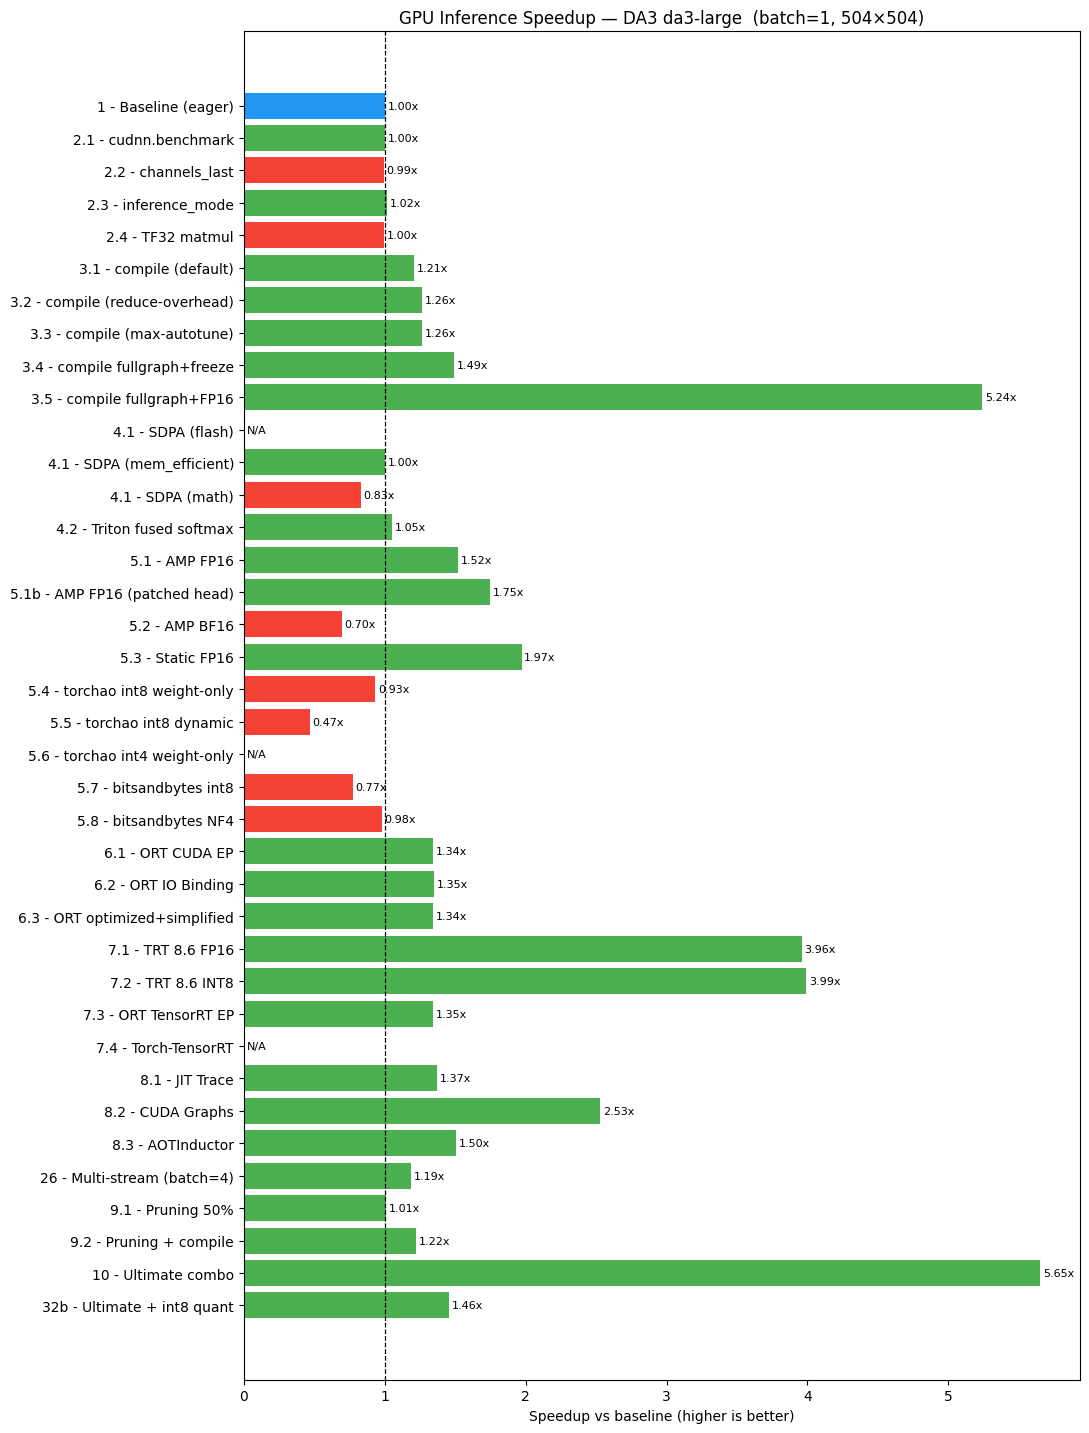

In [ ]:
#collapse-hide
def _speedup_chart(results, baseline_key, title):
    """Horizontal bar chart of speedup vs baseline."""
    bl = results.get(baseline_key, 1.0)
    items = list(results.items())
    names = [k for k, _ in items]
    speedups = [bl / v if (v == v and v > 0) else 0 for _, v in items]
    colors = [
        "#2196F3" if n == baseline_key
        else "#4CAF50" if s >= 1.0
        else "#F44336"
        for n, s in zip(names, speedups)
    ]

    fig, ax = plt.subplots(figsize=(11, max(5, len(names) * 0.38)))
    bars = ax.barh(names, speedups, color=colors)
    ax.axvline(x=1.0, color="black", linewidth=0.9, linestyle="--", label="baseline")
    ax.set_xlabel("Speedup vs baseline (higher is better)")
    ax.set_title(title)
    ax.invert_yaxis()

    for bar, s in zip(bars, speedups):
        lbl = f"{s:.2f}x" if s > 0 else "N/A"
        ax.text(
            bar.get_width() + 0.02,
            bar.get_y() + bar.get_height() / 2,
            lbl, va="center", fontsize=8,
        )

    plt.tight_layout()
    plt.show()
    plt.close(fig)


_speedup_chart(
    GPU_RESULTS,
    "1 - Baseline (eager)",
    f"GPU Inference Speedup — DA3 {MODEL_NAME}  (batch={BATCH}, 504×504)",
)


---
## Profiler deep-dive

Kernel-level breakdown of where time goes in the baseline model.

In [ ]:
#collapse-hide
try:
    torch.cuda.synchronize()
except RuntimeError:
    pass
gc.collect()
try:
    torch.cuda.empty_cache()
except RuntimeError:
    pass

prof_model = fresh_model()
from torch.profiler import profile as _torch_profile
with _torch_profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    profile_memory=True,
    with_flops=True,
) as prof:
    with torch.no_grad():
        for _ in range(10):
            prof_model(dummy_input)

print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=15))
cleanup()

[INFO ] using MLP layer as FFN
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls   Total FLOPs  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                           aten::linear         1.14%      18.635ms         6.14%     100.483ms      99.488us       0.000us         0.00%     653.8

---
## Cleanup

Remove temporary files generated during the benchmark run.

In [ ]:
#collapse-hide
import glob

_temp_patterns = [
    "model.onnx",
    "model_prep.onnx",
    "model_int8.onnx",
    "model_scripted.pt",
    "inference_benchmark_gpu.png",
]

for _pat in _temp_patterns:
    for _f in glob.glob(_pat):
        try:
            os.remove(_f)
            print(f"  removed {_f}")
        except OSError:
            pass

print("Cleanup done.")

  removed model.onnx
  removed model_prep.onnx
Cleanup done.


---
## What we learned

### The free wins (everyone should use these)

- **TF32 matmul (§2.4)** — On Ampere+ GPUs (A100, RTX 30xx, H100), TF32 rounds float32
  mantissa bits from 23 to 10 before the hardware tensor core matmul, then rounds back.
  About 2× faster for free. On pre-Ampere GPUs there are no TF32 tensor cores so
  this is a no-op.

- **`inference_mode` (§2.3)** — Stricter than `no_grad`: also disables autograd version
  counters and view tracking. A few percent faster, zero accuracy cost.

- **`model.half()` / Static FP16 (§5.3)** — Halves memory bandwidth. Tensor Cores do
  FP16 × FP16 → FP32 accumulation, so this is the single biggest easy win.

### The compiler wins (need Triton / Linux)

- **`torch.compile` (§3.1–3.3)** — TorchDynamo traces your model, TorchInductor compiles
  it via Triton. `reduce-overhead` uses CUDA Graphs internally — best for batch=1.

- **`fullgraph=True` + FP16 (§3.5)** — forces zero graph breaks. If it works (no dynamic
  control flow), the compiler optimizes the entire model as one fused kernel graph.
  Combined with FP16, this is the "GPT, Fast" recipe and our strongest PyTorch-native result.

### Memory optimization

- **FP16 / int8 quantization (§5)** halves or quarters the model footprint, leaving more
  room for larger batches.
- **Gradient checkpointing** (training) and **activation offloading** reduce peak
  memory during the backward pass — not applicable to pure inference, but important
  when fine-tuning.
- **ONNX graph optimization (§6.3)** — constant folding, dead-code elimination — removes
  redundant nodes, reducing both runtime and peak memory.

### Depth estimation gotchas

- **DA3's inner model uses `autocast(enabled=False)`** for the DPT depth head: this
  means AMP FP16 (§5.1) only accelerates the backbone (DinoV2), while the head always
  runs in FP32. Static FP16 (§5.3, `model.half()`) is more effective but may lose
  precision in the depth head's convolutions.

- **`addict.Dict` output** — DA3 returns an `addict.Dict` internally, which can cause
  graph breaks in `torch.compile` (§3) and issues with JIT trace (§8.1). The `DA3Depth`
  wrapper extracts just the depth tensor for compatibility.

### Why some techniques are slow or fail

- **`channels_last` (§2.2)** — Designed for CNNs (NHWC layout). DA3's backbone is mostly
  `nn.Linear`; only the DPT head's convolutions benefit, so the gain is tiny.

- **Torch-TensorRT (§7.4)** — `v2.5.x` requires TRT 10.x (SM ≥ 7.5); `v2.2.0` targets
  TRT 8.6 but has C++ ABI incompatibility with PyTorch 2.5. No compatible wheel exists.

- **bitsandbytes int8/NF4 (§5.7, §5.8)** — Custom dequantization kernels may not match
  hardware matmul throughput. Best for memory-constrained scenarios, not raw speed.

- **Pruning 50 % (§9.1)** — Unstructured sparsity without hardware 2:4 support (Ampere+)
  doesn't reduce compute.

- **TRT INT8 (§7.2)** — On Volta, many ViT layers (dominated by large matmuls) lack
  dedicated INT8 kernels and fall back to FP16. Expect marginal gains over pure FP16.

### The quantization landscape

- **torchao int8 weight-only (§5.4)** — 2× memory reduction; dequant fuses with `torch.compile`.
- **torchao int4 (§5.6)** — 4× reduction vs FP16; requires Ampere+ Tensor Cores.
- **TensorRT INT8 (§7.2)** — Calibration-based post-training quantization for max throughput.
- **ONNX int8 static** — Calibrated QDQ format for ORT deployment.

### References

1. **Depth Anything v3**: ByteDance-Seed, 2025. https://github.com/ByteDance-Seed/depth-anything-3
2. **DINOv2**: Oquab et al., 2023. https://arxiv.org/abs/2304.07193
3. **GPT, Fast**: PyTorch Blog, 2023. https://pytorch.org/blog/accelerating-generative-ai-2/
4. **LLM.int8()**: Dettmers et al., 2022. https://arxiv.org/abs/2208.07339
5. **QLoRA (NF4)**: Dettmers et al., 2023. https://arxiv.org/abs/2305.14314
6. **torch.compile**: PyTorch 2.0 blog, 2023.
7. **gpu-mode lectures**: https://github.com/gpu-mode/lectures
8. **FlashAttention**: Dao et al., 2022. https://arxiv.org/abs/2205.14135
9. **ONNX Runtime**: https://onnxruntime.ai/
10. **TensorRT 8.6**: https://docs.nvidia.com/deeplearning/tensorrt/archives/tensorrt-861/
11. **torchao**: https://github.com/pytorch/ao
12. **PyTorch Serve performance checklist**: https://docs.pytorch.org/serve/performance_checklist.html
13. **NVIDIA inference optimization**: https://developer.nvidia.com/blog/tag/inference-performance/
14. **ONNX Optimizer**: https://github.com/onnx/optimizer
15. **ONNX Simplifier**: https://github.com/onnxsim/onnxsim
16. **ONNX GraphSurgeon**: https://docs.nvidia.com/deeplearning/tensorrt/archives/tensorrt-861/onnx-graphsurgeon/docs/index.html